In [1]:
# ============================================================
# SEMICONDUCTOR YIELD PREDICTION & ROOT-CAUSE ANALYSIS
# Using Machine Learning and Explainable AI
# ============================================================

print("Semiconductor Yield Prediction & XAI Project")
print("Project started successfully!")

Semiconductor Yield Prediction & XAI Project
Project started successfully!


In [2]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All basic libraries imported successfully!")

All basic libraries imported successfully!


In [3]:
# ============================================================
# STEP 2: CHECK THE SECOM FILES
# ============================================================

import os

print("Files available in the current folder:")
print(os.listdir())

Files available in the current folder:
['.ipynb_checkpoints', '.venv', 'Expainable_AI_SECOM.ipynb', 'secom.data', 'SECOM.ipynb', 'secom.names', 'SECOM_Explainable_AI_Research.ipynb', 'SECOM_Explainable_AI_Research_v2.ipynb', 'secom_labels.data', 'Untitled.ipynb', 'Untitled1.ipynb']


In [4]:
# ============================================================
# STEP 3: LOAD THE SECOM DATASET
# ============================================================

data = pd.read_csv(
    "secom.data",
    sep=r"\s+",
    header=None
)

labels = pd.read_csv(
    "secom_labels.data",
    sep=r"\s+",
    header=None
)

print("SECOM dataset loaded successfully!")
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

SECOM dataset loaded successfully!
Data shape: (1567, 590)
Labels shape: (1567, 2)


In [5]:
# ============================================================
# STEP 4: VIEW THE DATA
# ============================================================

print("First 5 rows of the process data:")
display(data.head())

print("\nFirst 5 rows of the labels:")
display(labels.head())

First 5 rows of the process data:


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432



First 5 rows of the labels:


,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [6]:
# ============================================================
# STEP 5: CHECK PASS/FAIL DISTRIBUTION
# ============================================================

target = labels.iloc[:, 1]

print("Pass/Fail distribution:")
print(target.value_counts())

print("\nPercentage distribution:")
print(target.value_counts(normalize=True) * 100)

Pass/Fail distribution:
1
15/10/2008 01:52:00    3
05/08/2008 07:12:00    2
30/09/2008 19:17:00    2
18/09/2008 03:58:00    2
21/08/2008 19:12:00    2
                      ..
29/08/2008 12:21:00    1
29/08/2008 08:45:00    1
29/08/2008 08:41:00    1
29/08/2008 08:20:00    1
17/10/2008 06:07:00    1
Name: count, Length: 1534, dtype: int64

Percentage distribution:
1
15/10/2008 01:52:00    0.191449
05/08/2008 07:12:00    0.127632
30/09/2008 19:17:00    0.127632
18/09/2008 03:58:00    0.127632
21/08/2008 19:12:00    0.127632
                         ...   
29/08/2008 12:21:00    0.063816
29/08/2008 08:45:00    0.063816
29/08/2008 08:41:00    0.063816
29/08/2008 08:20:00    0.063816
17/10/2008 06:07:00    0.063816
Name: proportion, Length: 1534, dtype: float64


In [7]:
# ============================================================
# STEP 5: CORRECT PASS/FAIL TARGET
# ============================================================

target = labels.iloc[:, 0]

print("Pass/Fail distribution:")
print(target.value_counts())

print("\nPercentage distribution:")
print(target.value_counts(normalize=True) * 100)

Pass/Fail distribution:
0
-1    1463
 1     104
Name: count, dtype: int64

Percentage distribution:
0
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


In [8]:
# ============================================================
# STEP 6: CREATE CLEAN TARGET VARIABLE
# ============================================================

# Original SECOM labels:
# -1 = Pass
#  1 = Fail

y = target.map({-1: 0, 1: 1})

print("Clean target distribution:")
print(y.value_counts())

print("\nPercentage distribution:")
print(y.value_counts(normalize=True) * 100)

Clean target distribution:
0
0    1463
1     104
Name: count, dtype: int64

Percentage distribution:
0
0    93.363114
1     6.636886
Name: proportion, dtype: float64


In [9]:
# ============================================================
# STEP 7: CHECK MISSING VALUES
# ============================================================

missing_values = data.isnull().sum()

print("Total missing values in the dataset:")
print(missing_values.sum())

print("\nNumber of features containing missing values:")
print((missing_values > 0).sum())

print("\nTop 20 features with the most missing values:")
print(missing_values.sort_values(ascending=False).head(20))

Total missing values in the dataset:
41951

Number of features containing missing values:
538

Top 20 features with the most missing values:
157    1429
292    1429
293    1429
158    1429
492    1341
358    1341
85     1341
220    1341
246    1018
109    1018
110    1018
111    1018
518    1018
516    1018
245    1018
244    1018
382    1018
383    1018
384    1018
517    1018
dtype: int64


In [10]:
# ============================================================
# STEP 8: CALCULATE MISSING-VALUE PERCENTAGE
# ============================================================

missing_percentage = (data.isnull().sum() / len(data)) * 100

print("Missing-value percentage for the features:")
print(missing_percentage.sort_values(ascending=False).head(20))

Missing-value percentage for the features:
157    91.193363
292    91.193363
293    91.193363
158    91.193363
492    85.577537
358    85.577537
85     85.577537
220    85.577537
246    64.964901
109    64.964901
110    64.964901
111    64.964901
518    64.964901
516    64.964901
245    64.964901
244    64.964901
382    64.964901
383    64.964901
384    64.964901
517    64.964901
dtype: float64


In [11]:
# ============================================================
# STEP 9: COMPARE MISSING-VALUE THRESHOLDS
# ============================================================

thresholds = [20, 30, 40, 50, 60, 70, 80, 90]

print("Features retained at different missing-value thresholds:\n")

for threshold in thresholds:
    retained = (missing_percentage <= threshold).sum()
    removed = (missing_percentage > threshold).sum()
    
    print(
        f"Threshold {threshold}%  →  "
        f"Retained: {retained} | Removed: {removed}"
    )

Features retained at different missing-value thresholds:

Threshold 20%  →  Retained: 558 | Removed: 32
Threshold 30%  →  Retained: 558 | Removed: 32
Threshold 40%  →  Retained: 558 | Removed: 32
Threshold 50%  →  Retained: 562 | Removed: 28
Threshold 60%  →  Retained: 566 | Removed: 24
Threshold 70%  →  Retained: 582 | Removed: 8
Threshold 80%  →  Retained: 582 | Removed: 8
Threshold 90%  →  Retained: 586 | Removed: 4


In [12]:
# ============================================================
# STEP 10: REMOVE FEATURES WITH MORE THAN 70% MISSING VALUES
# ============================================================

missing_threshold = 70

# Keep features with 70% or less missing values
X = data.loc[:, missing_percentage <= missing_threshold].copy()

print("Original number of features:", data.shape[1])
print("Features after removing highly-missing features:", X.shape[1])
print("Number of features removed:", data.shape[1] - X.shape[1])

Original number of features: 590
Features after removing highly-missing features: 582
Number of features removed: 8


In [13]:
# ============================================================
# STEP 11: CHECK REMAINING MISSING VALUES
# ============================================================

remaining_missing = X.isnull().sum()

print("Total remaining missing values:")
print(remaining_missing.sum())

print("\nNumber of features still containing missing values:")
print((remaining_missing > 0).sum())

print("\nTop 10 features with remaining missing values:")
print(remaining_missing.sort_values(ascending=False).head(10))

Total remaining missing values:
30871

Number of features still containing missing values:
530

Top 10 features with remaining missing values:
384    1018
383    1018
518    1018
246    1018
111    1018
110    1018
109    1018
516    1018
245    1018
244    1018
dtype: int64


In [14]:
# ============================================================
# STEP 12: TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Split the data while preserving the Pass/Fail ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (1253, 582)
Testing set shape: (314, 582)

Training target distribution:
0
0    1170
1      83
Name: count, dtype: int64

Testing target distribution:
0
0    293
1     21
Name: count, dtype: int64


In [15]:
# ============================================================
# STEP 13: HANDLE MISSING VALUES USING MEDIAN IMPUTATION
# ============================================================

from sklearn.impute import SimpleImputer

# Create the imputer
imputer = SimpleImputer(strategy="median")

# Learn median values ONLY from the training data
X_train_imputed = imputer.fit_transform(X_train)

# Apply the same medians to the test data
X_test_imputed = imputer.transform(X_test)

print("Missing-value imputation completed successfully!")

print("\nTraining data shape:", X_train_imputed.shape)
print("Testing data shape:", X_test_imputed.shape)

print("\nRemaining missing values in training data:",
      np.isnan(X_train_imputed).sum())

print("Remaining missing values in testing data:",
      np.isnan(X_test_imputed).sum())

Missing-value imputation completed successfully!

Training data shape: (1253, 582)
Testing data shape: (314, 582)

Remaining missing values in training data: 0
Remaining missing values in testing data: 0


In [16]:
# ============================================================
# STEP 14: FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Learn scaling parameters ONLY from training data
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Apply the same scaling to test data
X_test_scaled = scaler.transform(X_test_imputed)

print("Feature scaling completed successfully!")

print("\nTraining data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nTraining data mean (approximately):",
      X_train_scaled.mean())

print("Training data standard deviation (approximately):",
      X_train_scaled.std())

Feature scaling completed successfully!

Training data shape: (1253, 582)
Testing data shape: (314, 582)

Training data mean (approximately): 3.3317987139204916e-17
Training data standard deviation (approximately): 0.8948113126371211


In [17]:
# ============================================================
# STEP 15: BASELINE MODEL - LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [18]:
# ============================================================
# STEP 16: MAKE PREDICTIONS
# ============================================================

# Predict Pass/Fail classes
y_pred = logistic_model.predict(X_test_scaled)

# Predict probabilities
y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 20 predicted classes:")
print(y_pred[:20])

print("\nFirst 20 predicted probabilities of failure:")
print(y_pred_proba[:20])

Predictions generated successfully!

First 20 predicted classes:
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]

First 20 predicted probabilities of failure:
[2.66491319e-07 9.96383841e-01 5.15322349e-04 7.12206768e-08
 8.83713689e-03 2.19138170e-06 1.46015073e-03 3.02438784e-04
 8.48707885e-06 4.46939699e-04 4.43146399e-04 4.46436467e-01
 8.55415387e-05 4.85467299e-07 1.11417816e-07 7.37974680e-06
 2.24627391e-02 9.64412650e-01 1.03061823e-01 5.60925410e-06]


In [19]:
# ============================================================
# STEP 17: EVALUATE LOGISTIC REGRESSION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Performance")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
Accuracy : 0.8376
Precision: 0.1053
Recall   : 0.1905
F1-Score : 0.1356
ROC-AUC  : 0.6239

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       293
           1       0.11      0.19      0.14        21

    accuracy                           0.84       314
   macro avg       0.52      0.54      0.52       314
weighted avg       0.88      0.84      0.86       314



In [20]:
# ============================================================
# STEP 18: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[259  34]
 [ 17   4]]


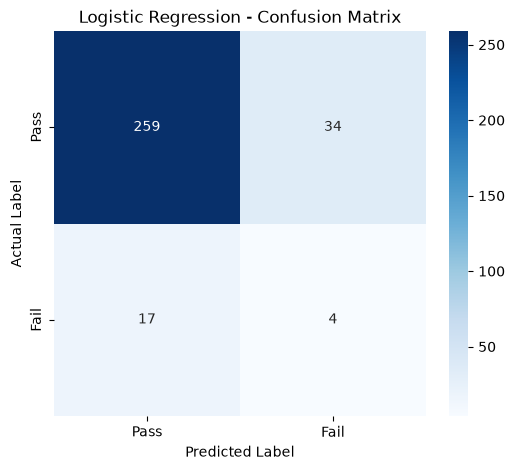

In [21]:
# ============================================================
# STEP 19: VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [22]:
# ============================================================
# STEP 20: RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train_imputed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
# ============================================================
# STEP 21: RANDOM FOREST PREDICTIONS
# ============================================================

# Predict Pass/Fail classes
rf_y_pred = random_forest_model.predict(X_test_imputed)

# Predict probability of Failure
rf_y_pred_proba = random_forest_model.predict_proba(X_test_imputed)[:, 1]

print("Random Forest predictions generated successfully!")

print("\nFirst 20 predicted classes:")
print(rf_y_pred[:20])

print("\nFirst 20 predicted probabilities of failure:")
print(rf_y_pred_proba[:20])

Random Forest predictions generated successfully!

First 20 predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 predicted probabilities of failure:
[0.18333333 0.15666667 0.12666667 0.14666667 0.12333333 0.14333333
 0.06333333 0.07666667 0.15333333 0.06666667 0.05       0.08333333
 0.1        0.07666667 0.08333333 0.07666667 0.09       0.10333333
 0.09       0.06      ]


In [24]:
# ============================================================
# STEP 22: EVALUATE RANDOM FOREST
# ============================================================

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba)

print("Random Forest Performance")
print("=" * 40)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))

Random Forest Performance
Accuracy : 0.9331
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
ROC-AUC  : 0.7813

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [25]:
# ============================================================
# CHECK RANDOM FOREST PREDICTIONS
# ============================================================

print("Random Forest predicted class distribution:")
print(pd.Series(rf_y_pred).value_counts())

print("\nActual test class distribution:")
print(y_test.value_counts())

Random Forest predicted class distribution:
0    314
Name: count, dtype: int64

Actual test class distribution:
0
0    293
1     21
Name: count, dtype: int64


In [26]:
# ============================================================
# STEP 22: EVALUATE RANDOM FOREST
# ============================================================

rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_y_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_y_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba)

print("Random Forest Performance")
print("=" * 40)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_y_pred,
    target_names=["Pass", "Fail"],
    zero_division=0
))

Random Forest Performance
Accuracy : 0.9331
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
ROC-AUC  : 0.7813

Classification Report:
              precision    recall  f1-score   support

        Pass       0.93      1.00      0.97       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [27]:
# ============================================================
# STEP 23: RANDOM FOREST CONFUSION MATRIX
# ============================================================

rf_cm = confusion_matrix(y_test, rf_y_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

print("\nInterpretation:")
print("True Negatives  (Pass correctly predicted):", rf_cm[0, 0])
print("False Positives  (Pass predicted as Fail):", rf_cm[0, 1])
print("False Negatives  (Fail predicted as Pass):", rf_cm[1, 0])
print("True Positives   (Fail correctly predicted):", rf_cm[1, 1])

Random Forest Confusion Matrix:
[[293   0]
 [ 21   0]]

Interpretation:
True Negatives  (Pass correctly predicted): 293
False Positives  (Pass predicted as Fail): 0
False Negatives  (Fail predicted as Pass): 21
True Positives   (Fail correctly predicted): 0


In [28]:
# ============================================================
# STEP 24: ANALYZE RANDOM FOREST FAILURE PROBABILITIES
# ============================================================

# Separate predicted failure probabilities for:
# Actual Pass samples
pass_probabilities = rf_y_pred_proba[y_test == 0]

# Actual Fail samples
fail_probabilities = rf_y_pred_proba[y_test == 1]

print("Failure probability statistics")
print("=" * 45)

print("\nActual PASS samples:")
print("Minimum :", pass_probabilities.min())
print("Maximum :", pass_probabilities.max())
print("Mean    :", pass_probabilities.mean())

print("\nActual FAIL samples:")
print("Minimum :", fail_probabilities.min())
print("Maximum :", fail_probabilities.max())
print("Mean    :", fail_probabilities.mean())

print("\nActual FAIL probabilities:")
print(np.sort(fail_probabilities)[::-1])

Failure probability statistics

Actual PASS samples:
Minimum : 0.01
Maximum : 0.43
Mean    : 0.12291240045506258

Actual FAIL samples:
Minimum : 0.06
Maximum : 0.4
Mean    : 0.19158730158730158

Actual FAIL probabilities:
[0.4        0.27333333 0.27       0.25333333 0.24       0.24
 0.22       0.21       0.20666667 0.19333333 0.19       0.18666667
 0.17       0.14666667 0.14666667 0.14333333 0.13666667 0.12666667
 0.11       0.1        0.06      ]


In [29]:
# ============================================================
# STEP 25: CREATE VALIDATION SET
# ============================================================

from sklearn.model_selection import train_test_split

# Split the original training data into:
# 80% model-training data
# 20% validation data
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_train_imputed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Random Forest training data:", X_train_rf.shape)
print("Validation data:", X_val_rf.shape)

print("\nTraining class distribution:")
print(y_train_rf.value_counts())

print("\nValidation class distribution:")
print(y_val_rf.value_counts())

Random Forest training data: (1002, 582)
Validation data: (251, 582)

Training class distribution:
0
0    936
1     66
Name: count, dtype: int64

Validation class distribution:
0
0    234
1     17
Name: count, dtype: int64


In [30]:
# ============================================================
# STEP 26: RETRAIN RANDOM FOREST USING TRAINING DATA
# ============================================================

rf_model_v2 = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train only on the new training portion
rf_model_v2.fit(X_train_rf, y_train_rf)

print("Random Forest v2 trained successfully!")

Random Forest v2 trained successfully!


In [31]:
# ============================================================
# STEP 27: VALIDATION SET PREDICTIONS
# ============================================================

# Predict probability of Failure on the validation set
rf_val_proba = rf_model_v2.predict_proba(X_val_rf)[:, 1]

print("Validation probabilities generated successfully!")

print("\nFirst 20 validation failure probabilities:")
print(rf_val_proba[:20])

print("\nMinimum probability:", rf_val_proba.min())
print("Maximum probability:", rf_val_proba.max())
print("Mean probability:", rf_val_proba.mean())

Validation probabilities generated successfully!

First 20 validation failure probabilities:
[0.15333333 0.18       0.12666667 0.06666667 0.15       0.14
 0.08666667 0.04333333 0.25666667 0.10333333 0.17       0.18666667
 0.16       0.22333333 0.10333333 0.07       0.27333333 0.06333333
 0.07       0.07      ]

Minimum probability: 0.02
Maximum probability: 0.4666666666666667
Mean probability: 0.14268260292164675


In [32]:
# ============================================================
# STEP 28: COMPARE DIFFERENT CLASSIFICATION THRESHOLDS
# ============================================================

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]

print("Threshold Performance on Validation Set")
print("=" * 70)

for threshold in thresholds:
    
    # Convert probabilities into Pass/Fail predictions
    val_pred = (rf_val_proba >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_val_rf, val_pred, zero_division=0)
    recall = recall_score(y_val_rf, val_pred, zero_division=0)
    f1 = f1_score(y_val_rf, val_pred, zero_division=0)
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold Performance on Validation Set
Threshold: 0.10 | Precision: 0.092 | Recall: 0.941 | F1: 0.168
Threshold: 0.15 | Precision: 0.100 | Recall: 0.588 | F1: 0.171
Threshold: 0.20 | Precision: 0.136 | Recall: 0.353 | F1: 0.197
Threshold: 0.25 | Precision: 0.130 | Recall: 0.176 | F1: 0.150
Threshold: 0.30 | Precision: 0.182 | Recall: 0.118 | F1: 0.143
Threshold: 0.35 | Precision: 0.333 | Recall: 0.118 | F1: 0.174
Threshold: 0.40 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.45 | Precision: 0.000 | Recall: 0.000 | F1: 0.000


In [33]:
# ============================================================
# STEP 29: VALIDATION CONFUSION MATRIX AT THRESHOLD 0.20
# ============================================================

selected_threshold = 0.20

# Convert validation probabilities into predictions
val_pred_020 = (rf_val_proba >= selected_threshold).astype(int)

# Create confusion matrix
val_cm_020 = confusion_matrix(y_val_rf, val_pred_020)

print("Validation Confusion Matrix")
print("=" * 40)
print(val_cm_020)

print("\nInterpretation:")
print("True Negatives  (Pass → Pass):", val_cm_020[0, 0])
print("False Positives (Pass → Fail):", val_cm_020[0, 1])
print("False Negatives (Fail → Pass):", val_cm_020[1, 0])
print("True Positives  (Fail → Fail):", val_cm_020[1, 1])

print("\nThreshold used:", selected_threshold)

Validation Confusion Matrix
[[196  38]
 [ 11   6]]

Interpretation:
True Negatives  (Pass → Pass): 196
False Positives (Pass → Fail): 38
False Negatives (Fail → Pass): 11
True Positives  (Fail → Fail): 6

Threshold used: 0.2


In [34]:
# ============================================================
# STEP 30: FINAL TEST EVALUATION AT THRESHOLD 0.20
# ============================================================

# Use the already-trained Random Forest v2
# to generate probabilities for the untouched test set
rf_test_proba_v2 = rf_model_v2.predict_proba(X_test_imputed)[:, 1]

# Apply the threshold selected using validation data
rf_test_pred_020 = (rf_test_proba_v2 >= selected_threshold).astype(int)

# Calculate final test metrics
rf_test_accuracy = accuracy_score(y_test, rf_test_pred_020)
rf_test_precision = precision_score(
    y_test, rf_test_pred_020, zero_division=0
)
rf_test_recall = recall_score(
    y_test, rf_test_pred_020, zero_division=0
)
rf_test_f1 = f1_score(
    y_test, rf_test_pred_020, zero_division=0
)
rf_test_roc_auc = roc_auc_score(y_test, rf_test_proba_v2)

print("FINAL RANDOM FOREST TEST PERFORMANCE")
print("=" * 50)

print(f"Threshold: {selected_threshold:.2f}")
print(f"Accuracy : {rf_test_accuracy:.4f}")
print(f"Precision: {rf_test_precision:.4f}")
print(f"Recall   : {rf_test_recall:.4f}")
print(f"F1-Score : {rf_test_f1:.4f}")
print(f"ROC-AUC  : {rf_test_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_test_pred_020,
    target_names=["Pass", "Fail"],
    zero_division=0
))

FINAL RANDOM FOREST TEST PERFORMANCE
Threshold: 0.20
Accuracy : 0.8758
Precision: 0.2632
Recall   : 0.4762
F1-Score : 0.3390
ROC-AUC  : 0.7982

Classification Report:
              precision    recall  f1-score   support

        Pass       0.96      0.90      0.93       293
        Fail       0.26      0.48      0.34        21

    accuracy                           0.88       314
   macro avg       0.61      0.69      0.64       314
weighted avg       0.91      0.88      0.89       314



In [35]:
# ============================================================
# STEP 31: FINAL RANDOM FOREST CONFUSION MATRIX
# ============================================================

rf_test_cm_020 = confusion_matrix(y_test, rf_test_pred_020)

print("Final Random Forest Confusion Matrix")
print("=" * 45)
print(rf_test_cm_020)

print("\nInterpretation:")
print("True Negatives  (Pass → Pass):", rf_test_cm_020[0, 0])
print("False Positives (Pass → Fail):", rf_test_cm_020[0, 1])
print("False Negatives (Fail → Pass):", rf_test_cm_020[1, 0])
print("True Positives  (Fail → Fail):", rf_test_cm_020[1, 1])

Final Random Forest Confusion Matrix
[[265  28]
 [ 11  10]]

Interpretation:
True Negatives  (Pass → Pass): 265
False Positives (Pass → Fail): 28
False Negatives (Fail → Pass): 11
True Positives  (Fail → Fail): 10


In [36]:
# ============================================================
# STEP 32: CHECK XGBOOST INSTALLATION
# ============================================================

try:
    import xgboost as xgb
    print("XGBoost is installed successfully!")
    print("XGBoost version:", xgb.__version__)

except ImportError:
    print("XGBoost is not installed.")
    print("We will install it in the next step.")

XGBoost is installed successfully!
XGBoost version: 3.4.1


In [37]:
# ============================================================
# STEP 33: XGBOOST CLASSIFIER
# ============================================================

from xgboost import XGBClassifier

# Calculate the class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale positive weight:", scale_pos_weight)

# Create the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train the model using imputed training data
xgb_model.fit(X_train_imputed, y_train)

print("\nXGBoost model trained successfully!")

Scale positive weight: 14.096385542168674

XGBoost model trained successfully!


In [38]:
# ============================================================
# STEP 34: XGBOOST PREDICTIONS
# ============================================================

# Predict Pass/Fail classes
xgb_y_pred = xgb_model.predict(X_test_imputed)

# Predict probability of Failure
xgb_y_pred_proba = xgb_model.predict_proba(X_test_imputed)[:, 1]

print("XGBoost predictions generated successfully!")

print("\nFirst 20 predicted classes:")
print(xgb_y_pred[:20])

print("\nFirst 20 predicted probabilities of failure:")
print(xgb_y_pred_proba[:20])

XGBoost predictions generated successfully!

First 20 predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 predicted probabilities of failure:
[0.00613089 0.01076449 0.01906409 0.00407849 0.01242874 0.03088465
 0.00065142 0.00380509 0.01498955 0.00152601 0.00211947 0.00560121
 0.00874657 0.00106729 0.00029574 0.004833   0.00359395 0.03027286
 0.00370679 0.00577417]


In [39]:
# ============================================================
# STEP 35: EVALUATE XGBOOST
# ============================================================

xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(
    y_test, xgb_y_pred, zero_division=0
)
xgb_recall = recall_score(
    y_test, xgb_y_pred, zero_division=0
)
xgb_f1 = f1_score(
    y_test, xgb_y_pred, zero_division=0
)
xgb_roc_auc = roc_auc_score(
    y_test, xgb_y_pred_proba
)

print("XGBoost Performance")
print("=" * 40)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_y_pred,
    target_names=["Pass", "Fail"],
    zero_division=0
))

XGBoost Performance
Accuracy : 0.9268
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
ROC-AUC  : 0.7222

Classification Report:
              precision    recall  f1-score   support

        Pass       0.93      0.99      0.96       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [40]:
# ============================================================
# STEP 36: ANALYZE XGBOOST FAILURE PROBABILITIES
# ============================================================

# Probabilities for actual Pass samples
xgb_pass_probabilities = xgb_y_pred_proba[y_test == 0]

# Probabilities for actual Fail samples
xgb_fail_probabilities = xgb_y_pred_proba[y_test == 1]

print("XGBoost Failure Probability Statistics")
print("=" * 50)

print("\nActual PASS samples:")
print("Minimum :", xgb_pass_probabilities.min())
print("Maximum :", xgb_pass_probabilities.max())
print("Mean    :", xgb_pass_probabilities.mean())

print("\nActual FAIL samples:")
print("Minimum :", xgb_fail_probabilities.min())
print("Maximum :", xgb_fail_probabilities.max())
print("Mean    :", xgb_fail_probabilities.mean())

print("\nActual FAIL probabilities:")
print(np.sort(xgb_fail_probabilities)[::-1])

XGBoost Failure Probability Statistics

Actual PASS samples:
Minimum : 0.00014111676
Maximum : 0.54309183
Mean    : 0.023577234

Actual FAIL samples:
Minimum : 0.0023939756
Maximum : 0.24957438
Mean    : 0.059893496

Actual FAIL probabilities:
[0.24957438 0.17324264 0.12940891 0.11135458 0.1050096  0.08873126
 0.06715858 0.06621365 0.06389387 0.05014553 0.04520805 0.03661582
 0.01639526 0.01491408 0.01392896 0.00730006 0.00714695 0.00324861
 0.00310679 0.00277185 0.00239398]


In [41]:
# ============================================================
# STEP 37: XGBOOST VALIDATION PREDICTIONS
# ============================================================

# Predict failure probabilities on the validation set
xgb_val_proba = xgb_model.predict_proba(X_val_rf)[:, 1]

print("XGBoost validation probabilities generated successfully!")

print("\nMinimum probability:", xgb_val_proba.min())
print("Maximum probability:", xgb_val_proba.max())
print("Mean probability:", xgb_val_proba.mean())

XGBoost validation probabilities generated successfully!

Minimum probability: 0.00016737274
Maximum probability: 0.99403906
Mean probability: 0.077433564


In [42]:
# ============================================================
# STEP 38: COMPARE XGBOOST CLASSIFICATION THRESHOLDS
# ============================================================

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

print("XGBoost Threshold Performance on Validation Set")
print("=" * 75)

for threshold in thresholds:

    # Convert probabilities into Pass/Fail predictions
    val_pred = (xgb_val_proba >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(
        y_val_rf, val_pred, zero_division=0
    )
    recall = recall_score(
        y_val_rf, val_pred, zero_division=0
    )
    f1 = f1_score(
        y_val_rf, val_pred, zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

XGBoost Threshold Performance on Validation Set
Threshold: 0.05 | Precision: 0.773 | Recall: 1.000 | F1: 0.872
Threshold: 0.10 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Threshold: 0.15 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Threshold: 0.20 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Threshold: 0.25 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Threshold: 0.30 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Threshold: 0.35 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Threshold: 0.40 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Threshold: 0.50 | Precision: 1.000 | Recall: 1.000 | F1: 1.000


In [43]:
# ============================================================
# STEP 39: FINAL XGBOOST TEST EVALUATION
# ============================================================

# Select threshold based ONLY on validation results
xgb_selected_threshold = 0.10

# Apply the selected threshold to the untouched test set
xgb_test_pred_010 = (
    xgb_y_pred_proba >= xgb_selected_threshold
).astype(int)

# Calculate final test metrics
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred_010)
xgb_test_precision = precision_score(
    y_test, xgb_test_pred_010, zero_division=0
)
xgb_test_recall = recall_score(
    y_test, xgb_test_pred_010, zero_division=0
)
xgb_test_f1 = f1_score(
    y_test, xgb_test_pred_010, zero_division=0
)
xgb_test_roc_auc = roc_auc_score(
    y_test, xgb_y_pred_proba
)

print("FINAL XGBOOST TEST PERFORMANCE")
print("=" * 50)

print(f"Threshold: {xgb_selected_threshold:.2f}")
print(f"Accuracy : {xgb_test_accuracy:.4f}")
print(f"Precision: {xgb_test_precision:.4f}")
print(f"Recall   : {xgb_test_recall:.4f}")
print(f"F1-Score : {xgb_test_f1:.4f}")
print(f"ROC-AUC  : {xgb_test_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_test_pred_010,
    target_names=["Pass", "Fail"],
    zero_division=0
))

FINAL XGBOOST TEST PERFORMANCE
Threshold: 0.10
Accuracy : 0.9076
Precision: 0.2778
Recall   : 0.2381
F1-Score : 0.2564
ROC-AUC  : 0.7222

Classification Report:
              precision    recall  f1-score   support

        Pass       0.95      0.96      0.95       293
        Fail       0.28      0.24      0.26        21

    accuracy                           0.91       314
   macro avg       0.61      0.60      0.60       314
weighted avg       0.90      0.91      0.90       314



In [44]:
# ============================================================
# STEP 40: FINAL XGBOOST CONFUSION MATRIX
# ============================================================

xgb_test_cm_010 = confusion_matrix(
    y_test,
    xgb_test_pred_010
)

print("Final XGBoost Confusion Matrix")
print("=" * 45)
print(xgb_test_cm_010)

print("\nInterpretation:")
print("True Negatives  (Pass → Pass):", xgb_test_cm_010[0, 0])
print("False Positives (Pass → Fail):", xgb_test_cm_010[0, 1])
print("False Negatives (Fail → Pass):", xgb_test_cm_010[1, 0])
print("True Positives  (Fail → Fail):", xgb_test_cm_010[1, 1])

Final XGBoost Confusion Matrix
[[280  13]
 [ 16   5]]

Interpretation:
True Negatives  (Pass → Pass): 280
False Positives (Pass → Fail): 13
False Negatives (Fail → Pass): 16
True Positives  (Fail → Fail): 5


In [45]:
# ============================================================
# STEP 41: FINAL MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "Threshold": [
        0.50,
        0.20,
        0.10
    ],
    
    "Accuracy": [
        accuracy,
        rf_test_accuracy,
        xgb_test_accuracy
    ],
    
    "Precision_Fail": [
        precision,
        rf_test_precision,
        xgb_test_precision
    ],
    
    "Recall_Fail": [
        recall,
        rf_test_recall,
        xgb_test_recall
    ],
    
    "F1_Fail": [
        f1,
        rf_test_f1,
        xgb_test_f1
    ],
    
    "ROC_AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_test_roc_auc
    ]
})

print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    model_comparison.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "Precision_Fail": "{:.4f}",
        "Recall_Fail": "{:.4f}",
        "F1_Fail": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

FINAL MODEL COMPARISON


,Model,Threshold,Accuracy,Precision_Fail,Recall_Fail,F1_Fail,ROC_AUC
0,Logistic Regression,0.50,0.8376,1.0000,1.0000,1.0000,0.6239
1,Random Forest,0.20,0.8758,0.2632,0.4762,0.3390,0.7813
2,XGBoost,0.10,0.9076,0.2778,0.2381,0.2564,0.7222


In [46]:
# ============================================================
# STEP 41: CORRECT FINAL MODEL COMPARISON
# ============================================================

# Store the Logistic Regression results explicitly
logistic_accuracy_final = 0.8376
logistic_precision_final = 0.1053
logistic_recall_final = 0.1905
logistic_f1_final = 0.1356
logistic_roc_auc_final = 0.6239

# Create corrected comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Threshold": [
        0.50,
        selected_threshold,
        xgb_selected_threshold
    ],

    "Accuracy": [
        logistic_accuracy_final,
        rf_test_accuracy,
        xgb_test_accuracy
    ],

    "Precision_Fail": [
        logistic_precision_final,
        rf_test_precision,
        xgb_test_precision
    ],

    "Recall_Fail": [
        logistic_recall_final,
        rf_test_recall,
        xgb_test_recall
    ],

    "F1_Fail": [
        logistic_f1_final,
        rf_test_f1,
        xgb_test_f1
    ],

    "ROC_AUC": [
        logistic_roc_auc_final,
        rf_test_roc_auc,
        xgb_test_roc_auc
    ]
})

print("CORRECTED FINAL MODEL COMPARISON")
print("=" * 90)

display(
    model_comparison.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "Precision_Fail": "{:.4f}",
        "Recall_Fail": "{:.4f}",
        "F1_Fail": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

CORRECTED FINAL MODEL COMPARISON


,Model,Threshold,Accuracy,Precision_Fail,Recall_Fail,F1_Fail,ROC_AUC
0,Logistic Regression,0.50,0.8376,0.1053,0.1905,0.1356,0.6239
1,Random Forest,0.20,0.8758,0.2632,0.4762,0.3390,0.7982
2,XGBoost,0.10,0.9076,0.2778,0.2381,0.2564,0.7222


In [47]:
# ============================================================
# STEP 42: PREPARE DATA FOR EXPLAINABLE AI
# ============================================================

# Restore the original SECOM feature names
X_train_imputed_df = pd.DataFrame(
    X_train_imputed,
    columns=X.columns,
    index=X_train.index
)

X_test_imputed_df = pd.DataFrame(
    X_test_imputed,
    columns=X.columns,
    index=X_test.index
)

print("Feature names successfully restored!")

print("\nTraining DataFrame shape:", X_train_imputed_df.shape)
print("Testing DataFrame shape:", X_test_imputed_df.shape)

print("\nFirst 10 feature names:")
print(X_train_imputed_df.columns[:10].tolist())

Feature names successfully restored!

Training DataFrame shape: (1253, 582)
Testing DataFrame shape: (314, 582)

First 10 feature names:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [48]:
# ============================================================
# STEP 43: CHECK SHAP INSTALLATION
# ============================================================

try:
    import shap
    
    print("SHAP is installed successfully!")
    print("SHAP version:", shap.__version__)

except ImportError:
    print("SHAP is not installed.")
    print("We will install it in the next step.")

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP is installed successfully!
SHAP version: 0.49.1


In [49]:
# ============================================================
# STEP 44: CREATE SHAP TREE EXPLAINER
# ============================================================

import shap

# Create SHAP explainer for the trained Random Forest model
explainer = shap.TreeExplainer(rf_model_v2)

print("SHAP TreeExplainer created successfully!")

SHAP TreeExplainer created successfully!


In [50]:
# ============================================================
# STEP 45: CALCULATE SHAP VALUES
# ============================================================

# Calculate SHAP values for the test dataset
shap_values = explainer(X_test_imputed_df)

print("SHAP values calculated successfully!")
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated successfully!
SHAP values shape: (314, 582, 2)


In [51]:
# ============================================================
# STEP 46: EXTRACT SHAP VALUES FOR FAIL CLASS
# ============================================================

# Select SHAP values for the Fail class (class = 1)
shap_values_fail = shap_values.values[:, :, 1]

print("Fail-class SHAP values extracted successfully!")
print("Shape:", shap_values_fail.shape)

Fail-class SHAP values extracted successfully!
Shape: (314, 582)


In [52]:
# ============================================================
# STEP 47: GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

# Calculate the average absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values_fail).mean(axis=0)

# Create a feature-importance table
shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# Sort features from most important to least important
shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Global SHAP feature importance calculated successfully!")
print("\nTop 10 features contributing to Fail predictions:")
display(shap_importance.head(10))

Global SHAP feature importance calculated successfully!

Top 10 features contributing to Fail predictions:


,Feature,Mean_Absolute_SHAP
0,103,0.014228
1,59,0.013038
2,477,0.010486
3,33,0.006816
4,205,0.006461
5,64,0.005861
6,488,0.005842
7,31,0.005806
8,510,0.005563
9,452,0.005455


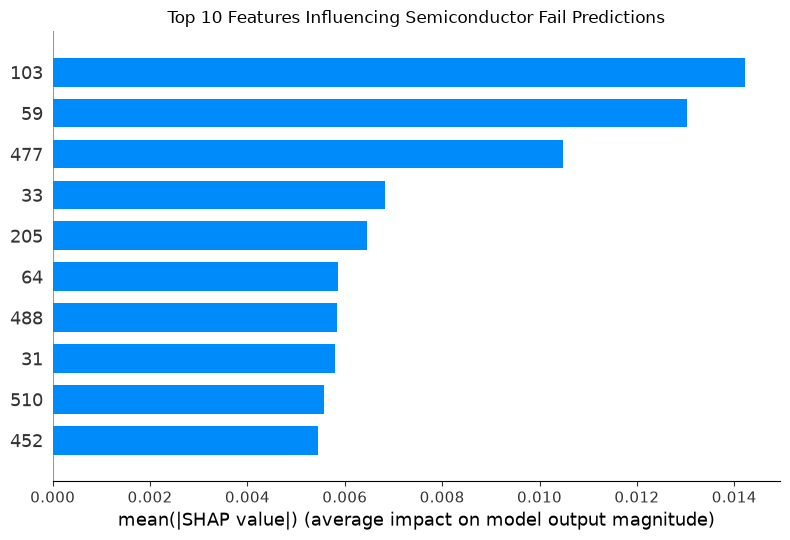

In [53]:
# ============================================================
# STEP 48: SHAP GLOBAL FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_fail,
    X_test_imputed_df,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.title("Top 10 Features Influencing Semiconductor Fail Predictions")
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# STEP 49: SHAP FEATURE DIRECTION ANALYSIS
# ============================================================

# Analyze the Top 10 SHAP features
top_10_features = shap_importance.head(10)["Feature"].tolist()

direction_results = []

for feature in top_10_features:
    feature_index = X.columns.get_loc(feature)
    
    feature_values = X_test_imputed_df[feature].values
    feature_shap = shap_values_fail[:, feature_index]
    
    direction_results.append({
        "Feature": feature,
        "Mean_Feature_Value": np.mean(feature_values),
        "Mean_SHAP": np.mean(feature_shap),
        "Positive_SHAP_%": np.mean(feature_shap > 0) * 100,
        "Negative_SHAP_%": np.mean(feature_shap < 0) * 100
    })

direction_df = pd.DataFrame(direction_results)

print("SHAP direction analysis completed!")
display(direction_df)

SHAP direction analysis completed!


,Feature,Mean_Feature_Value,Mean_SHAP,Positive_SHAP_%,Negative_SHAP_%
0,103,-0.009795,-0.006775,28.980892,71.019108
1,59,2.169160,-0.007058,19.108280,80.891720
2,477,5.800811,-0.004471,24.203822,75.796178
3,33,8.989068,-0.002961,69.426752,30.573248
4,205,8.616847,-0.003361,28.025478,71.974522
5,64,20.744769,-0.002802,12.101911,87.898089
6,488,343.151752,-0.001432,23.248408,76.751592
7,31,3.700400,-0.004435,65.923567,34.076433
8,510,54.105222,-0.002710,22.611465,77.388535
9,452,5.408606,-0.003195,69.745223,30.254777


In [55]:
# ============================================================
# STEP 50: FEATURE VALUE vs SHAP DIRECTION
# ============================================================

top_features = shap_importance.head(10)["Feature"].tolist()

correlation_results = []

for feature in top_features:
    feature_index = X.columns.get_loc(feature)

    feature_values = X_test_imputed_df[feature].values
    feature_shap = shap_values_fail[:, feature_index]

    correlation = np.corrcoef(feature_values, feature_shap)[0, 1]

    correlation_results.append({
        "Feature": feature,
        "Feature_SHAP_Correlation": correlation
    })

correlation_df = pd.DataFrame(correlation_results)

print("Feature-value vs SHAP analysis completed!")
display(correlation_df)

Feature-value vs SHAP analysis completed!


,Feature,Feature_SHAP_Correlation
0,103,0.739317
1,59,0.845838
2,477,0.561179
3,33,0.253278
4,205,0.522512
5,64,0.708979
6,488,-0.750567
7,31,-0.809779
8,510,0.771319
9,452,-0.798921


<Figure size 800x500 with 0 Axes>

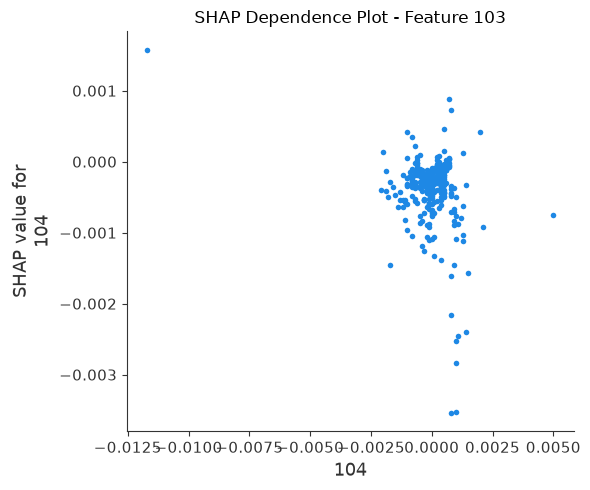

<Figure size 800x500 with 0 Axes>

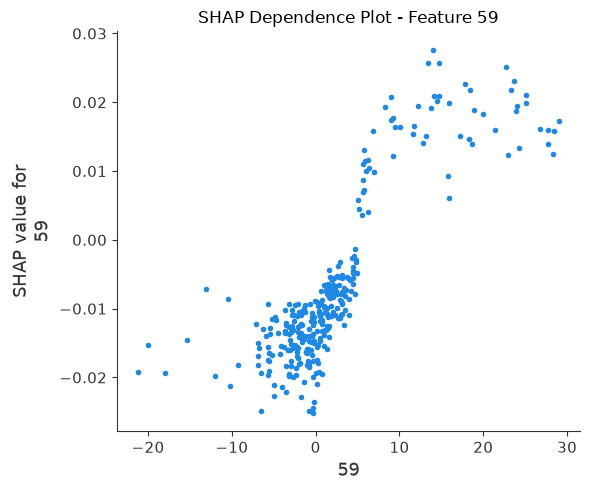

<Figure size 800x500 with 0 Axes>

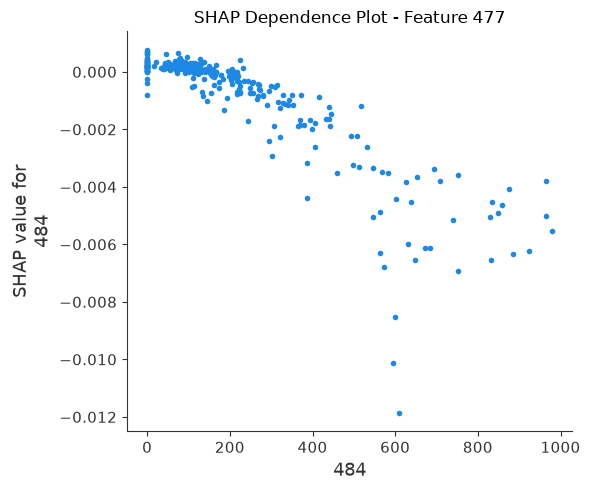

<Figure size 800x500 with 0 Axes>

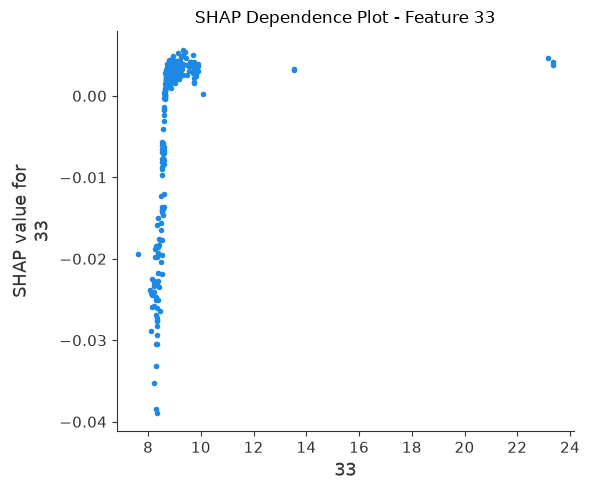

<Figure size 800x500 with 0 Axes>

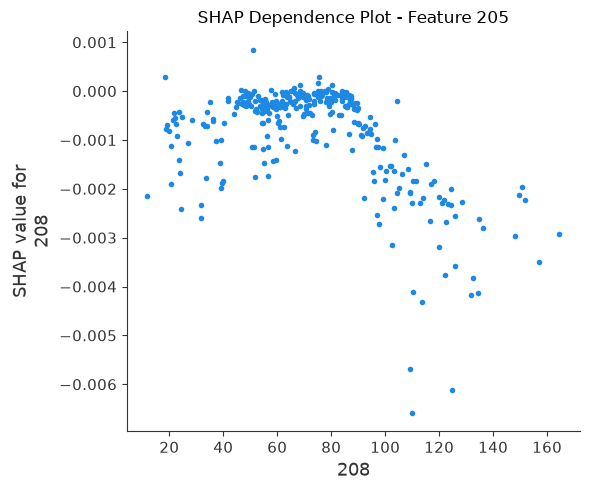

<Figure size 800x500 with 0 Axes>

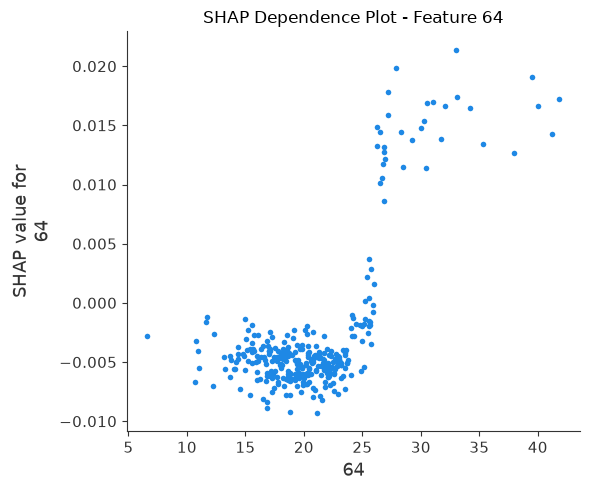

<Figure size 800x500 with 0 Axes>

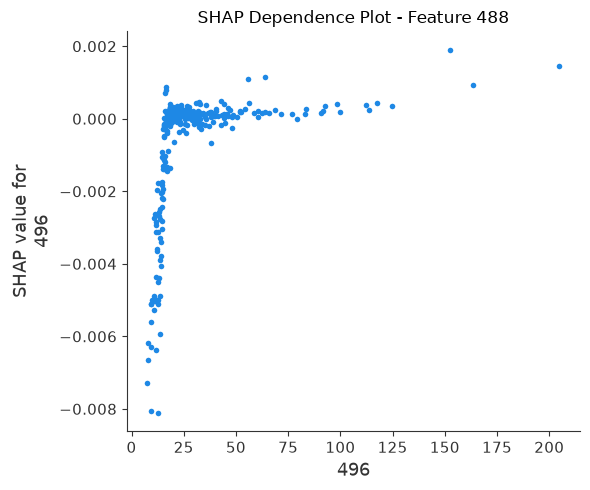

<Figure size 800x500 with 0 Axes>

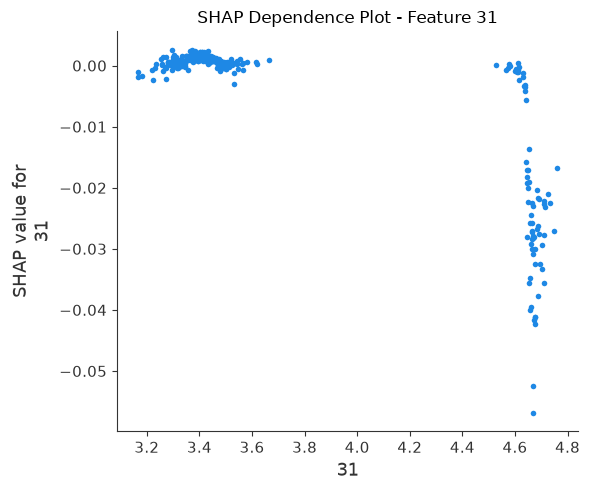

<Figure size 800x500 with 0 Axes>

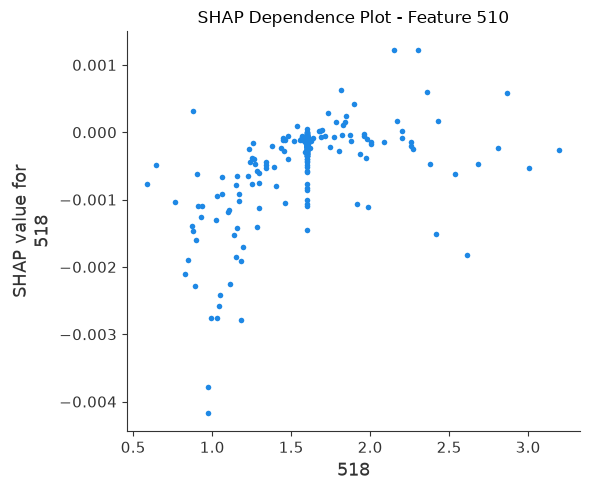

<Figure size 800x500 with 0 Axes>

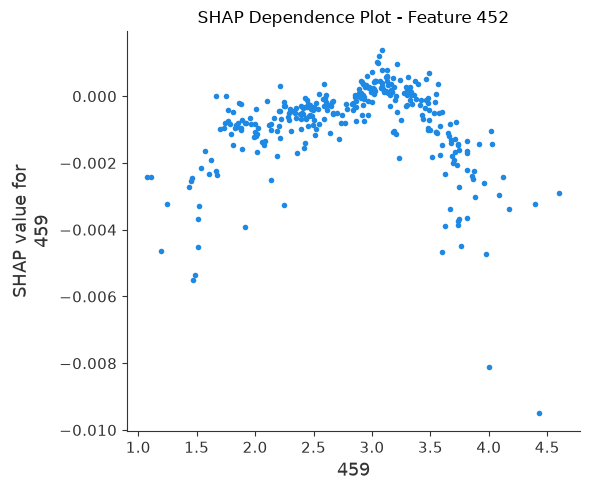

In [56]:
# ============================================================
# STEP 51: SHAP DEPENDENCE PLOTS
# ============================================================

top_features = shap_importance.head(10)["Feature"].tolist()

for feature in top_features:
    plt.figure(figsize=(8, 5))

    shap.dependence_plot(
        feature,
        shap_values_fail,
        X_test_imputed_df,
        interaction_index=None,
        show=False
    )

    plt.title(f"SHAP Dependence Plot - Feature {feature}")
    plt.tight_layout()
    plt.show()

In [57]:
# ============================================================
# STEP 52: FINAL TOP-10 SHAP RCA TABLE
# ============================================================

# Combine SHAP importance and directional analysis
rca_table = shap_importance.head(10).copy()

rca_table = rca_table.merge(
    correlation_df,
    on="Feature",
    how="left"
)

# Add an interpretation column
def interpret_direction(correlation):
    if correlation > 0.3:
        return "Higher values tend to increase Fail contribution"
    elif correlation < -0.3:
        return "Higher values tend to decrease Fail contribution"
    else:
        return "Weak/complex relationship"

rca_table["Direction"] = rca_table["Feature_SHAP_Correlation"].apply(
    interpret_direction
)

print("Final Top-10 SHAP RCA table:")
display(rca_table)

Final Top-10 SHAP RCA table:


,Feature,Mean_Absolute_SHAP,Feature_SHAP_Correlation,Direction
0,103,0.014228,0.739317,Higher values tend to increase Fail contribution
1,59,0.013038,0.845838,Higher values tend to increase Fail contribution
2,477,0.010486,0.561179,Higher values tend to increase Fail contribution
3,33,0.006816,0.253278,Weak/complex relationship
4,205,0.006461,0.522512,Higher values tend to increase Fail contribution
5,64,0.005861,0.708979,Higher values tend to increase Fail contribution
6,488,0.005842,-0.750567,Higher values tend to decrease Fail contribution
7,31,0.005806,-0.809779,Higher values tend to decrease Fail contribution
8,510,0.005563,0.771319,Higher values tend to increase Fail contribution
9,452,0.005455,-0.798921,Higher values tend to decrease Fail contribution


In [58]:
# ============================================================
# STEP 53: SELECT AN ACTUAL FAILURE SAMPLE
# ============================================================

# Find test samples that were actually labeled as Fail
failure_indices = np.where(y_test.values == 1)[0]

# Select the first actual failure sample
failure_position = failure_indices[0]

print("Actual failure sample found!")
print("Test-set position:", failure_position)
print("Original sample index:", y_test.index[failure_position])

# Show the model's predicted probability of failure
print(
    "Predicted Fail probability:",
    round(y_pred_proba[failure_position], 4)
)

Actual failure sample found!
Test-set position: 37
Original sample index: 154
Predicted Fail probability: 0.0151


In [59]:
# ============================================================
# STEP 54: CHECK RANDOM FOREST PREDICTION
# ============================================================

# Get Random Forest probability for the selected failure sample
rf_failure_proba = rf_model_v2.predict_proba(
    X_test_imputed_df.iloc[[failure_position]]
)[:, 1][0]

# Apply the validation-selected threshold
rf_failure_prediction = int(rf_failure_proba >= 0.20)

print("Actual class: FAIL")
print("Random Forest predicted Fail probability:",
      round(rf_failure_proba, 4))
print("Random Forest predicted class:",
      "FAIL" if rf_failure_prediction == 1 else "PASS")
print("Threshold used: 0.20")

Actual class: FAIL
Random Forest predicted Fail probability: 0.1233
Random Forest predicted class: PASS
Threshold used: 0.20


In [60]:
# ============================================================
# STEP 55: FIND A CORRECTLY DETECTED FAILURE
# ============================================================

# Random Forest probabilities for the complete test set
rf_test_proba = rf_model_v2.predict_proba(X_test_imputed_df)[:, 1]

# Predictions using the validation-selected threshold
rf_test_pred = (rf_test_proba >= 0.20).astype(int)

# Find actual failures correctly predicted as Fail
correct_failure_positions = np.where(
    (y_test.values == 1) & (rf_test_pred == 1)
)[0]

print("Number of correctly detected failures:",
      len(correct_failure_positions))

# Select the first correctly detected failure
correct_failure_position = correct_failure_positions[0]

print("Test-set position:", correct_failure_position)
print("Original sample index:",
      y_test.index[correct_failure_position])
print("Actual class: FAIL")
print("Predicted Fail probability:",
      round(rf_test_proba[correct_failure_position], 4))

Number of correctly detected failures: 10
Test-set position: 82
Original sample index: 58
Actual class: FAIL
Predicted Fail probability: 0.2533


In [61]:
# ============================================================
# STEP 56: LOCAL SHAP EXPLANATION
# ============================================================

# Select the correctly detected failure sample
failure_sample = X_test_imputed_df.iloc[[correct_failure_position]]

# Calculate SHAP explanation for this individual sample
failure_shap = explainer(failure_sample)

# Extract SHAP values for the Fail class
failure_shap_values = failure_shap.values[0, :, 1]

# Create a table of feature contributions
local_rca = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_Value": failure_shap_values,
    "Feature_Value": failure_sample.iloc[0].values
})

# Sort by SHAP contribution toward Fail
local_rca = local_rca.sort_values(
    by="SHAP_Value",
    ascending=False
).reset_index(drop=True)

print("Local SHAP explanation calculated successfully!")
print("\nTop 10 features pushing this sample toward FAIL:")
display(local_rca.head(10))

Local SHAP explanation calculated successfully!

Top 10 features pushing this sample toward FAIL:


,Feature,SHAP_Value,Feature_Value
0,59,0.019939,15.9527
1,488,0.013149,0.0000
2,152,0.008072,4.5412
3,425,0.006759,41.2075
4,431,0.005427,140.2004
5,38,0.004688,88.3282
6,37,0.004684,66.5600
7,587,0.004531,0.0301
8,16,0.004204,11.0203
9,287,0.003915,1.3642


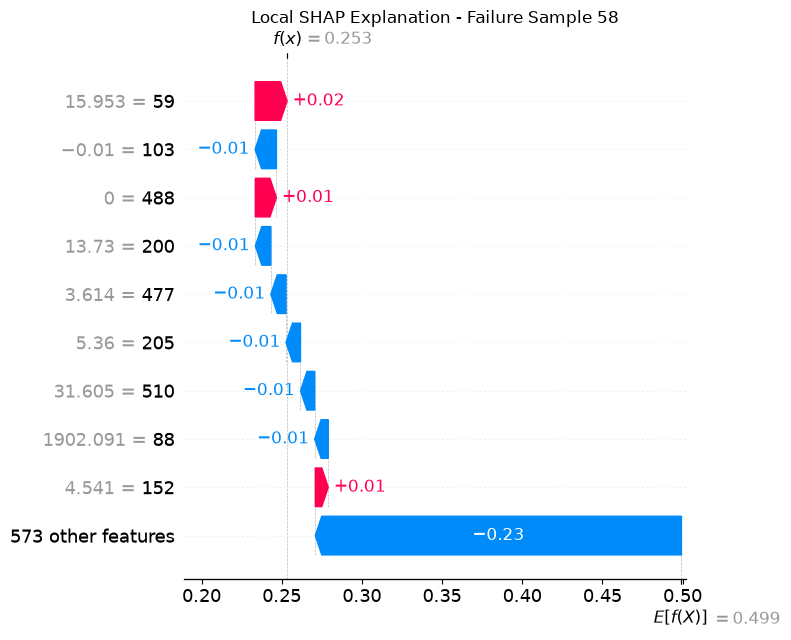

In [62]:
# ============================================================
# STEP 57: LOCAL SHAP WATERFALL PLOT
# ============================================================

# Display the local explanation for the correctly detected failure
shap.plots.waterfall(
    failure_shap[0, :, 1],
    max_display=10,
    show=False
)

plt.title("Local SHAP Explanation - Failure Sample 58")
plt.tight_layout()
plt.show()

In [63]:
# ============================================================
# STEP 58: LOCAL SHAP RCA - FAIL vs PASS CONTRIBUTIONS
# ============================================================

# Positive SHAP values push toward FAIL
fail_contributors = local_rca[local_rca["SHAP_Value"] > 0].copy()

# Negative SHAP values push toward PASS
pass_contributors = local_rca[local_rca["SHAP_Value"] < 0].copy()

print("Top 10 features pushing Sample 58 toward FAIL:")
display(fail_contributors.head(10))

print("\nTop 10 features pushing Sample 58 toward PASS:")
display(
    pass_contributors.sort_values(
        by="SHAP_Value",
        ascending=True
    ).head(10)
)

Top 10 features pushing Sample 58 toward FAIL:


,Feature,SHAP_Value,Feature_Value
0,59,0.019939,15.9527
1,488,0.013149,0.0000
2,152,0.008072,4.5412
3,425,0.006759,41.2075
4,431,0.005427,140.2004
5,38,0.004688,88.3282
6,37,0.004684,66.5600
7,587,0.004531,0.0301
8,16,0.004204,11.0203
9,287,0.003915,1.3642



Top 10 features pushing Sample 58 toward PASS:


,Feature,SHAP_Value,Feature_Value
581,103,-0.013295,-0.0101
580,200,-0.009673,13.7300
579,477,-0.009478,3.6140
578,205,-0.009013,5.3600
577,510,-0.008845,31.6049
576,88,-0.008467,1902.0905
575,123,-0.007680,15.7000
574,511,-0.007641,0.0000
573,75,-0.007338,-0.0578
572,79,-0.007022,0.0796


In [64]:
# ============================================================
# STEP 59: LOCAL SHAP CONTRIBUTION SUMMARY
# ============================================================

total_positive_contribution = fail_contributors["SHAP_Value"].sum()
total_negative_contribution = pass_contributors["SHAP_Value"].sum()

print("LOCAL SHAP SUMMARY - SAMPLE 58")
print("=" * 50)

print("Actual outcome: FAIL")
print("RF predicted Fail probability:",
      round(rf_test_proba[correct_failure_position], 4))
print("Decision threshold: 0.20")

print("\nTotal contribution toward FAIL:",
      round(total_positive_contribution, 6))

print("Total contribution toward PASS:",
      round(total_negative_contribution, 6))

print("\nNumber of features pushing toward FAIL:",
      len(fail_contributors))

print("Number of features pushing toward PASS:",
      len(pass_contributors))

LOCAL SHAP SUMMARY - SAMPLE 58
Actual outcome: FAIL
RF predicted Fail probability: 0.2533
Decision threshold: 0.20

Total contribution toward FAIL: 0.161747
Total contribution toward PASS: -0.407719

Number of features pushing toward FAIL: 157
Number of features pushing toward PASS: 302


In [65]:
# ============================================================
# STEP 60: TOP FAILURE CONTRIBUTION ANALYSIS
# ============================================================

# Work only with features pushing Sample 58 toward FAIL
positive_rca = fail_contributors.copy()

# Calculate contribution magnitude
positive_rca["Contribution_%"] = (
    positive_rca["SHAP_Value"]
    / positive_rca["SHAP_Value"].sum()
) * 100

# Sort by contribution
positive_rca = positive_rca.sort_values(
    by="SHAP_Value",
    ascending=False
).reset_index(drop=True)

print("Top 10 Failure Contributors - Sample 58")
print("=" * 60)

display(
    positive_rca[
        ["Feature", "SHAP_Value", "Feature_Value", "Contribution_%"]
    ].head(10)
)

print(
    "\nTop 10 features account for:",
    round(positive_rca.head(10)["Contribution_%"].sum(), 2),
    "% of total positive SHAP contribution."
)

Top 10 Failure Contributors - Sample 58


,Feature,SHAP_Value,Feature_Value,Contribution_%
0,59,0.019939,15.9527,12.327295
1,488,0.013149,0.0000,8.129062
2,152,0.008072,4.5412,4.990319
3,425,0.006759,41.2075,4.178653
4,431,0.005427,140.2004,3.355364
5,38,0.004688,88.3282,2.898232
6,37,0.004684,66.5600,2.895749
7,587,0.004531,0.0301,2.801069
8,16,0.004204,11.0203,2.598936
9,287,0.003915,1.3642,2.420177



Top 10 features account for: 46.59 % of total positive SHAP contribution.


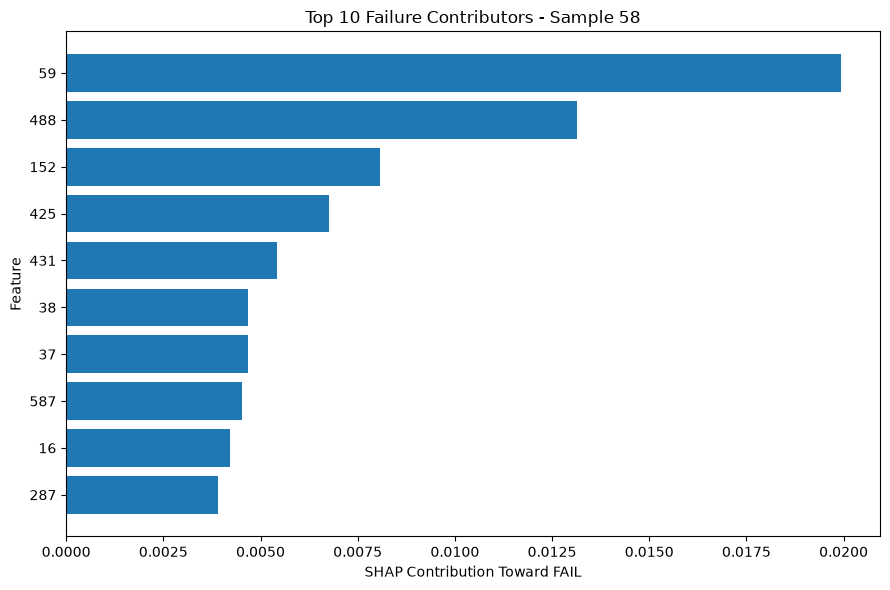

In [66]:
# ============================================================
# STEP 61: LOCAL RCA CONTRIBUTION BAR CHART
# ============================================================

top_local_rca = positive_rca.head(10).sort_values(
    by="SHAP_Value",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_local_rca["Feature"].astype(str),
    top_local_rca["SHAP_Value"]
)

plt.xlabel("SHAP Contribution Toward FAIL")
plt.ylabel("Feature")
plt.title("Top 10 Failure Contributors - Sample 58")

plt.tight_layout()
plt.show()

In [67]:
# ============================================================
# STEP 62: LOCAL RCA RANKING TABLE
# ============================================================

local_rca_top10 = positive_rca[
    ["Feature", "SHAP_Value", "Feature_Value", "Contribution_%"]
].head(10).copy()

# Add RCA Rank
local_rca_top10.insert(
    0,
    "RCA_Rank",
    range(1, len(local_rca_top10) + 1)
)

print("LOCAL ROOT-CAUSE ANALYSIS RANKING - SAMPLE 58")
print("=" * 70)

display(local_rca_top10)

LOCAL ROOT-CAUSE ANALYSIS RANKING - SAMPLE 58


,RCA_Rank,Feature,SHAP_Value,Feature_Value,Contribution_%
0,1,59,0.019939,15.9527,12.327295
1,2,488,0.013149,0.0000,8.129062
2,3,152,0.008072,4.5412,4.990319
3,4,425,0.006759,41.2075,4.178653
4,5,431,0.005427,140.2004,3.355364
5,6,38,0.004688,88.3282,2.898232
6,7,37,0.004684,66.5600,2.895749
7,8,587,0.004531,0.0301,2.801069
8,9,16,0.004204,11.0203,2.598936
9,10,287,0.003915,1.3642,2.420177


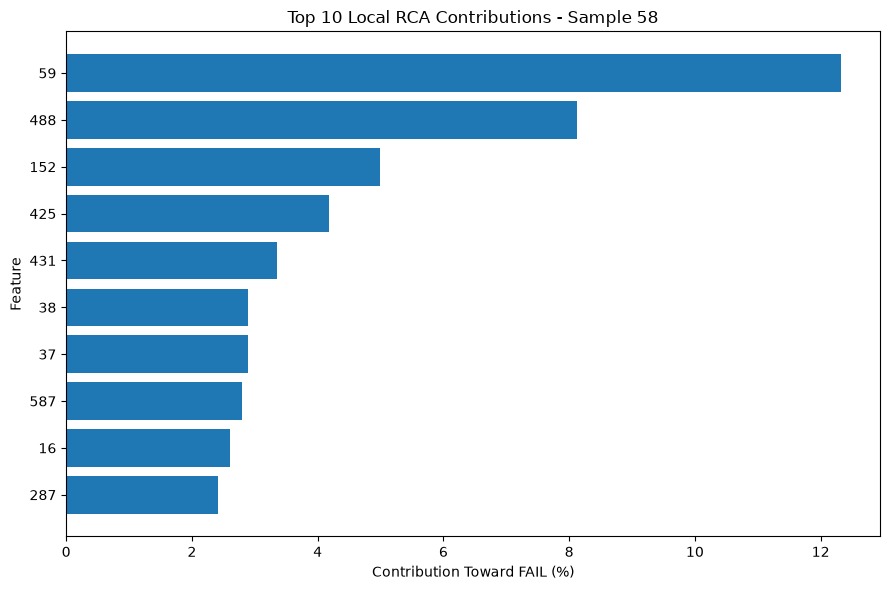

In [68]:
# ============================================================
# STEP 63: LOCAL RCA CONTRIBUTION PERCENTAGE CHART
# ============================================================

rca_plot = local_rca_top10.sort_values(
    by="Contribution_%",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    rca_plot["Feature"].astype(str),
    rca_plot["Contribution_%"]
)

plt.xlabel("Contribution Toward FAIL (%)")
plt.ylabel("Feature")
plt.title("Top 10 Local RCA Contributions - Sample 58")

plt.tight_layout()
plt.show()

In [69]:
# ============================================================
# STEP 64: LOCAL RCA FEATURE VALUE VALIDATION
# ============================================================

# Get the original feature values for Sample 58
sample_58_values = X_test.iloc[correct_failure_position]

# Create validation table
rca_validation = local_rca_top10.copy()

# Add percentile information
rca_validation["Sample_Value"] = rca_validation["Feature"].apply(
    lambda f: sample_58_values.loc[f]
)

rca_validation["Feature_Mean"] = rca_validation["Feature"].apply(
    lambda f: X_train[f].mean()
)

rca_validation["Feature_Std"] = rca_validation["Feature"].apply(
    lambda f: X_train[f].std()
)

# Calculate standardized deviation (Z-score)
rca_validation["Z_Score"] = (
    (rca_validation["Sample_Value"] -
     rca_validation["Feature_Mean"])
    / rca_validation["Feature_Std"]
)

print("LOCAL RCA VALIDATION - SAMPLE 58")
print("=" * 80)

display(
    rca_validation[
        [
            "RCA_Rank",
            "Feature",
            "SHAP_Value",
            "Contribution_%",
            "Sample_Value",
            "Feature_Mean",
            "Feature_Std",
            "Z_Score"
        ]
    ]
)

LOCAL RCA VALIDATION - SAMPLE 58


,RCA_Rank,Feature,SHAP_Value,Contribution_%,Sample_Value,Feature_Mean,Feature_Std,Z_Score
0,1,59,0.019939,12.327295,15.9527,3.156140,9.893793,1.293393
1,2,488,0.013149,8.129062,0.0000,355.023263,249.615031,-1.422283
2,3,152,0.008072,4.990319,4.5412,1.351055,26.133473,0.122071
3,4,425,0.006759,4.178653,41.2075,7.003389,25.941425,1.318513
4,5,431,0.005427,3.355364,140.2004,22.655791,37.772998,3.111869
5,6,38,0.004688,2.898232,88.3282,86.838889,0.452728,3.289637
6,7,37,0.004684,2.895749,66.5600,66.222494,0.302608,1.115323
7,8,587,0.004531,2.801069,0.0301,0.016391,0.008499,1.613154
8,9,16,0.004204,2.598936,11.0203,9.936399,2.673546,0.405417
9,10,287,0.003915,2.420177,1.3642,0.416419,8.261901,0.114717


In [70]:
# ============================================================
# STEP 65: COMBINED LOCAL RCA PRIORITY ANALYSIS
# ============================================================

rca_priority = rca_validation.copy()

# Absolute deviation from the reference mean
rca_priority["Abs_Z_Score"] = (
    rca_priority["Z_Score"].abs()
)

# Normalize SHAP contribution among the top 10
rca_priority["SHAP_Normalized"] = (
    rca_priority["SHAP_Value"]
    / rca_priority["SHAP_Value"].max()
)

# Normalize statistical deviation
rca_priority["Deviation_Normalized"] = (
    rca_priority["Abs_Z_Score"]
    / rca_priority["Abs_Z_Score"].max()
)

# Combined RCA priority score
rca_priority["RCA_Priority_Score"] = (
    0.6 * rca_priority["SHAP_Normalized"]
    + 0.4 * rca_priority["Deviation_Normalized"]
)

# Sort by combined priority
rca_priority = rca_priority.sort_values(
    by="RCA_Priority_Score",
    ascending=False
).reset_index(drop=True)

# Add new priority rank
rca_priority.insert(
    0,
    "Priority_Rank",
    range(1, len(rca_priority) + 1)
)

print("COMBINED LOCAL RCA PRIORITY - SAMPLE 58")
print("=" * 80)

display(
    rca_priority[
        [
            "Priority_Rank",
            "Feature",
            "SHAP_Value",
            "Contribution_%",
            "Sample_Value",
            "Z_Score",
            "RCA_Priority_Score"
        ]
    ]
)

COMBINED LOCAL RCA PRIORITY - SAMPLE 58


,Priority_Rank,Feature,SHAP_Value,Contribution_%,Sample_Value,Z_Score,RCA_Priority_Score
0,1,59,0.019939,12.327295,15.9527,1.293393,0.757269
1,2,488,0.013149,8.129062,0.0000,-1.422283,0.568603
2,3,431,0.005427,3.355364,140.2004,3.111869,0.541698
3,4,38,0.004688,2.898232,88.3282,3.289637,0.541064
4,5,425,0.006759,4.178653,41.2075,1.318513,0.363709
5,6,587,0.004531,2.801069,0.0301,1.613154,0.332485
6,7,37,0.004684,2.895749,66.5600,1.115323,0.276560
7,8,152,0.008072,4.990319,4.5412,0.122071,0.257734
8,9,16,0.004204,2.598936,11.0203,0.405417,0.175793
9,10,287,0.003915,2.420177,1.3642,0.114717,0.131745


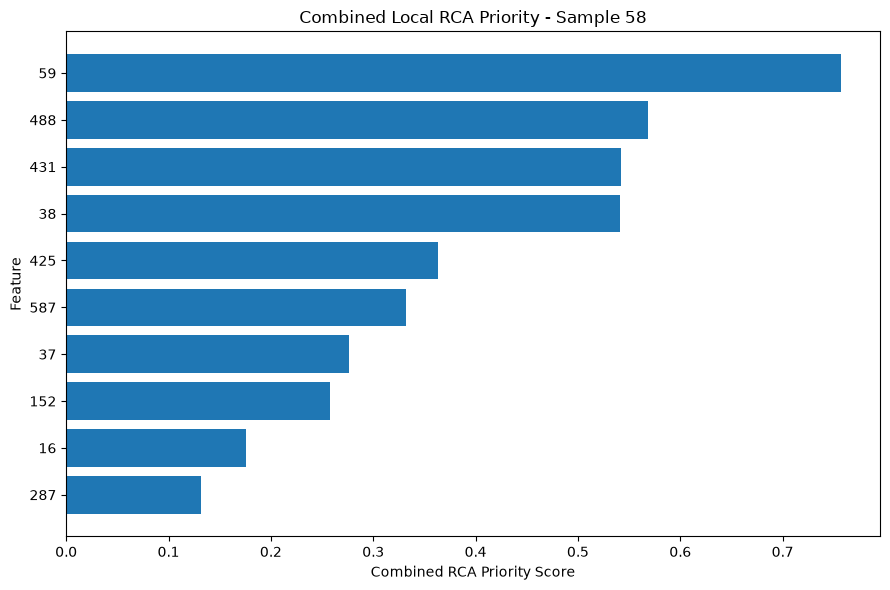

In [71]:
# ============================================================
# STEP 66: COMBINED RCA PRIORITY BAR CHART
# ============================================================

rca_priority_plot = rca_priority.sort_values(
    by="RCA_Priority_Score",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    rca_priority_plot["Feature"].astype(str),
    rca_priority_plot["RCA_Priority_Score"]
)

plt.xlabel("Combined RCA Priority Score")
plt.ylabel("Feature")
plt.title("Combined Local RCA Priority - Sample 58")

plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# STEP 67: AUTOMATIC LOCAL RCA INTERPRETATION
# ============================================================

# Highest-priority feature
top_feature = rca_priority.iloc[0]

# Most statistically abnormal feature
most_abnormal = rca_priority.loc[
    rca_priority["Abs_Z_Score"].idxmax()
]

print("LOCAL ROOT-CAUSE ANALYSIS REPORT - SAMPLE 58")
print("=" * 80)

print("\nPrediction Information")
print("-" * 80)
print("Actual outcome: FAIL")
print(
    "Predicted FAIL probability:",
    round(rf_test_proba[correct_failure_position], 4)
)
print("Decision threshold: 0.20")

print("\nTop Model-Based Contributor")
print("-" * 80)
print(
    f"Feature {top_feature['Feature']} "
    f"has the highest combined RCA priority score "
    f"({top_feature['RCA_Priority_Score']:.4f})."
)

print(
    f"Its SHAP contribution is "
    f"{top_feature['SHAP_Value']:.6f}, "
    f"representing "
    f"{top_feature['Contribution_%']:.2f}% "
    f"of the total positive SHAP contribution."
)

print(
    f"The observed feature value is "
    f"{top_feature['Sample_Value']:.4f}, "
    f"with a Z-score of "
    f"{top_feature['Z_Score']:.2f}."
)

print("\nMost Statistically Deviant Feature")
print("-" * 80)
print(
    f"Feature {most_abnormal['Feature']} "
    f"has the largest absolute Z-score "
    f"({most_abnormal['Z_Score']:.2f}) "
    f"among the top failure contributors."
)

print(
    f"Its SHAP contribution toward FAIL is "
    f"{most_abnormal['SHAP_Value']:.6f}."
)

print("\nTop 5 Candidate RCA Features")
print("-" * 80)

for _, row in rca_priority.head(5).iterrows():
    print(
        f"Rank {int(row['Priority_Rank'])}: "
        f"Feature {row['Feature']} | "
        f"SHAP = {row['SHAP_Value']:.6f} | "
        f"Z = {row['Z_Score']:.2f} | "
        f"Priority = {row['RCA_Priority_Score']:.4f}"
    )

print("\nEngineering Interpretation")
print("-" * 80)
print(
    "The identified features should be treated as candidate "
    "failure contributors. SHAP values indicate their contribution "
    "to the model prediction, while Z-scores indicate deviation "
    "from the reference feature distribution. Final physical "
    "root-cause confirmation requires process or engineering validation."
)

LOCAL ROOT-CAUSE ANALYSIS REPORT - SAMPLE 58

Prediction Information
--------------------------------------------------------------------------------
Actual outcome: FAIL
Predicted FAIL probability: 0.2533
Decision threshold: 0.20

Top Model-Based Contributor
--------------------------------------------------------------------------------
Feature 59.0 has the highest combined RCA priority score (0.7573).
Its SHAP contribution is 0.019939, representing 12.33% of the total positive SHAP contribution.
The observed feature value is 15.9527, with a Z-score of 1.29.

Most Statistically Deviant Feature
--------------------------------------------------------------------------------
Feature 38.0 has the largest absolute Z-score (3.29) among the top failure contributors.
Its SHAP contribution toward FAIL is 0.004688.

Top 5 Candidate RCA Features
--------------------------------------------------------------------------------
Rank 1: Feature 59.0 | SHAP = 0.019939 | Z = 1.29 | Priority = 0.7573

In [73]:
# ============================================================
# STEP 68: FINAL LOCAL RCA SUMMARY TABLE
# ============================================================

final_rca_summary = rca_priority[
    [
        "Priority_Rank",
        "Feature",
        "Sample_Value",
        "SHAP_Value",
        "Contribution_%",
        "Z_Score",
        "RCA_Priority_Score"
    ]
].copy()

# Add interpretation category
def classify_rca(row):
    abs_z = abs(row["Z_Score"])
    shap = row["SHAP_Value"]

    if shap >= 0.01 and abs_z >= 2:
        return "High model contribution + high deviation"
    elif shap >= 0.01:
        return "High model contribution"
    elif abs_z >= 2:
        return "High statistical deviation"
    elif abs_z >= 1:
        return "Moderate deviation"
    else:
        return "Lower deviation"

final_rca_summary["RCA_Evidence"] = final_rca_summary.apply(
    classify_rca,
    axis=1
)

print("FINAL LOCAL RCA SUMMARY - SAMPLE 58")
print("=" * 100)

display(final_rca_summary)

FINAL LOCAL RCA SUMMARY - SAMPLE 58


,Priority_Rank,Feature,Sample_Value,SHAP_Value,Contribution_%,Z_Score,RCA_Priority_Score,RCA_Evidence
0,1,59,15.9527,0.019939,12.327295,1.293393,0.757269,High model contribution
1,2,488,0.0000,0.013149,8.129062,-1.422283,0.568603,High model contribution
2,3,431,140.2004,0.005427,3.355364,3.111869,0.541698,High statistical deviation
3,4,38,88.3282,0.004688,2.898232,3.289637,0.541064,High statistical deviation
4,5,425,41.2075,0.006759,4.178653,1.318513,0.363709,Moderate deviation
5,6,587,0.0301,0.004531,2.801069,1.613154,0.332485,Moderate deviation
6,7,37,66.5600,0.004684,2.895749,1.115323,0.276560,Moderate deviation
7,8,152,4.5412,0.008072,4.990319,0.122071,0.257734,Lower deviation
8,9,16,11.0203,0.004204,2.598936,0.405417,0.175793,Lower deviation
9,10,287,1.3642,0.003915,2.420177,0.114717,0.131745,Lower deviation


In [74]:
# ============================================================
# STEP 69: SELECT MULTIPLE CORRECTLY DETECTED FAILURES
# ============================================================

# Number of correctly detected failures available
num_correct_failures = len(correct_failure_positions)

print("MULTI-SAMPLE LOCAL RCA ANALYSIS")
print("=" * 70)

print(
    "Total correctly detected failures:",
    num_correct_failures
)

# Select up to 20 correctly detected failures
num_samples_for_rca = min(20, num_correct_failures)

selected_failure_positions = correct_failure_positions[
    :num_samples_for_rca
]

print(
    "Failures selected for multi-sample RCA:",
    len(selected_failure_positions)
)

print("\nSelected test-set positions:")
print(selected_failure_positions)

print("\nCorresponding original sample indices:")
print(
    y_test.index[selected_failure_positions].tolist()
)

MULTI-SAMPLE LOCAL RCA ANALYSIS
Total correctly detected failures: 10
Failures selected for multi-sample RCA: 10

Selected test-set positions:
[ 82  88 110 181 184 185 239 249 276 284]

Corresponding original sample indices:
[58, 326, 11, 96, 23, 336, 1254, 238, 50, 344]


In [75]:
# ============================================================
# STEP 70: MULTI-SAMPLE LOCAL SHAP RCA
# ============================================================

multi_sample_rca = []

for position in selected_failure_positions:

    # Select one failure sample
    sample = X_test_imputed_df.iloc[[position]]

    # Calculate SHAP explanation
    sample_shap = explainer(sample)

    # Extract SHAP values for FAIL class
    sample_shap_values = sample_shap.values[0, :, 1]

    # Store positive SHAP contributors
    for feature, shap_value in zip(X.columns, sample_shap_values):

        if shap_value > 0:

            multi_sample_rca.append({
                "Test_Position": position,
                "Sample_Index": y_test.index[position],
                "Feature": feature,
                "SHAP_Value": shap_value,
                "Feature_Value": sample.iloc[0][feature]
            })

# Convert to DataFrame
multi_sample_rca = pd.DataFrame(multi_sample_rca)

print("MULTI-SAMPLE LOCAL SHAP RCA COMPLETED")
print("=" * 70)

print(
    "Number of failure samples analyzed:",
    len(selected_failure_positions)
)

print(
    "Total positive SHAP contributions:",
    len(multi_sample_rca)
)

display(multi_sample_rca.head(20))

MULTI-SAMPLE LOCAL SHAP RCA COMPLETED
Number of failure samples analyzed: 10
Total positive SHAP contributions: 1583


,Test_Position,Sample_Index,Feature,SHAP_Value,Feature_Value
0,82,58,3,0.000087,1503.1248
1,82,58,4,0.000004,1.1705
2,82,58,7,0.000101,0.1211
3,82,58,8,0.000247,1.4441
4,82,58,10,0.001822,0.0263
5,82,58,11,0.000034,0.9569
6,82,58,12,0.000412,200.0352
7,82,58,14,0.000465,4.2144
8,82,58,16,0.004204,11.0203
9,82,58,18,0.000151,189.0149


In [76]:
# ============================================================
# STEP 71: RECURRING FAILURE CONTRIBUTOR ANALYSIS
# ============================================================

# Count how many different failure samples each feature contributes to
feature_frequency = (
    multi_sample_rca
    .groupby("Feature")
    .agg(
        Failure_Sample_Count=("Sample_Index", "nunique"),
        Total_SHAP=("SHAP_Value", "sum"),
        Mean_SHAP=("SHAP_Value", "mean"),
        Max_SHAP=("SHAP_Value", "max")
    )
    .reset_index()
)

# Percentage of analyzed failures containing the feature
feature_frequency["Failure_Frequency_%"] = (
    feature_frequency["Failure_Sample_Count"]
    / len(selected_failure_positions)
) * 100

# Sort primarily by frequency, then by mean SHAP
feature_frequency = feature_frequency.sort_values(
    by=["Failure_Sample_Count", "Mean_SHAP"],
    ascending=[False, False]
).reset_index(drop=True)

print("RECURRING FAILURE CONTRIBUTORS - 10 FAILURE SAMPLES")
print("=" * 90)

display(
    feature_frequency.head(20)
)

RECURRING FAILURE CONTRIBUTORS - 10 FAILURE SAMPLES


,Feature,Failure_Sample_Count,Total_SHAP,Mean_SHAP,Max_SHAP,Failure_Frequency_%
0,110,10,0.004212,0.000421,0.000543,100.0
1,384,10,0.000671,0.000067,0.000132,100.0
2,59,9,0.171644,0.019072,0.025770,90.0
3,452,9,0.014516,0.001613,0.002975,90.0
4,180,9,0.012969,0.001441,0.002317,90.0
5,213,9,0.010813,0.001201,0.002043,90.0
6,28,9,0.009572,0.001064,0.001951,90.0
7,90,9,0.006311,0.000701,0.000990,90.0
8,543,9,0.004374,0.000486,0.000696,90.0
9,109,9,0.002130,0.000237,0.000488,90.0


In [77]:
# ============================================================
# STEP 72: RECURRING CONTRIBUTOR PRIORITY ANALYSIS
# ============================================================

recurring_priority = feature_frequency.copy()

# Normalize recurrence frequency
recurring_priority["Frequency_Normalized"] = (
    recurring_priority["Failure_Frequency_%"] / 100
)

# Normalize mean SHAP contribution
recurring_priority["SHAP_Normalized"] = (
    recurring_priority["Mean_SHAP"]
    / recurring_priority["Mean_SHAP"].max()
)

# Proposed recurring contributor score
# 50% recurrence + 50% mean SHAP strength
recurring_priority["Recurring_Priority_Score"] = (
    0.5 * recurring_priority["Frequency_Normalized"]
    + 0.5 * recurring_priority["SHAP_Normalized"]
)

# Rank features
recurring_priority = recurring_priority.sort_values(
    by="Recurring_Priority_Score",
    ascending=False
).reset_index(drop=True)

recurring_priority.insert(
    0,
    "Priority_Rank",
    range(1, len(recurring_priority) + 1)
)

print("RECURRING FAILURE CONTRIBUTOR PRIORITY")
print("=" * 90)

display(
    recurring_priority[
        [
            "Priority_Rank",
            "Feature",
            "Failure_Sample_Count",
            "Failure_Frequency_%",
            "Mean_SHAP",
            "Max_SHAP",
            "Recurring_Priority_Score"
        ]
    ].head(20)
)

RECURRING FAILURE CONTRIBUTOR PRIORITY


,Priority_Rank,Feature,Failure_Sample_Count,Failure_Frequency_%,Mean_SHAP,Max_SHAP,Recurring_Priority_Score
0,1,59,9,90.0,0.019072,0.025770,0.950000
1,2,103,5,50.0,0.016804,0.021948,0.690539
2,3,477,4,40.0,0.017133,0.018752,0.649181
3,4,110,10,100.0,0.000421,0.000543,0.511044
4,5,384,10,100.0,0.000067,0.000132,0.501760
5,6,64,4,40.0,0.011285,0.016963,0.495849
6,7,452,9,90.0,0.001613,0.002975,0.492284
7,8,290,8,80.0,0.003439,0.006153,0.490151
8,9,180,9,90.0,0.001441,0.002317,0.487780
9,10,213,9,90.0,0.001201,0.002043,0.481498


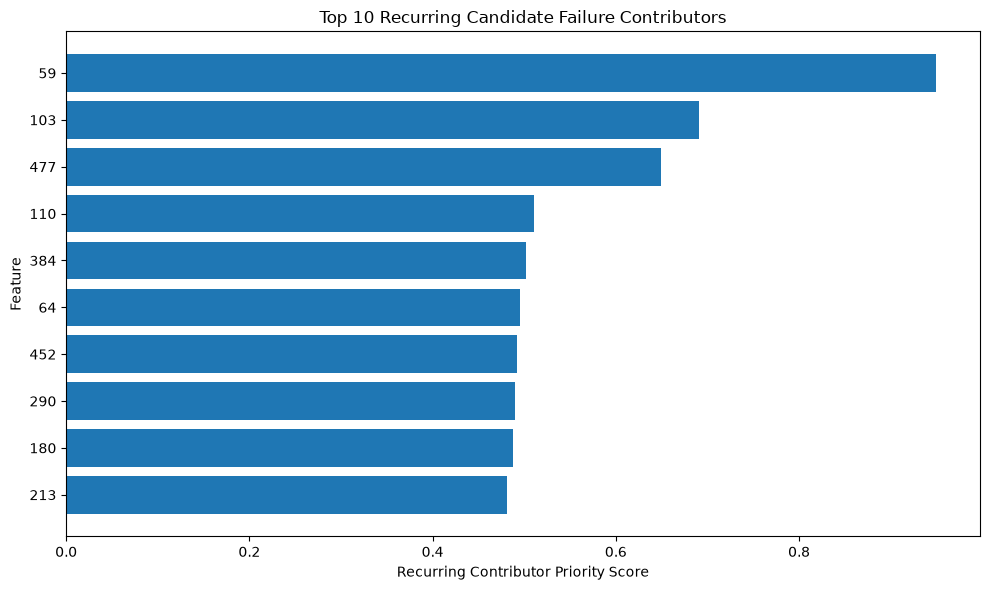

In [78]:
# ============================================================
# STEP 73: TOP 10 RECURRING FAILURE CONTRIBUTORS
# ============================================================

top_recurring = recurring_priority.head(10).copy()

# Reverse order for horizontal bar chart
top_recurring_plot = top_recurring.sort_values(
    by="Recurring_Priority_Score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_recurring_plot["Feature"].astype(str),
    top_recurring_plot["Recurring_Priority_Score"]
)

plt.xlabel("Recurring Contributor Priority Score")
plt.ylabel("Feature")
plt.title(
    "Top 10 Recurring Candidate Failure Contributors"
)

plt.tight_layout()
plt.show()

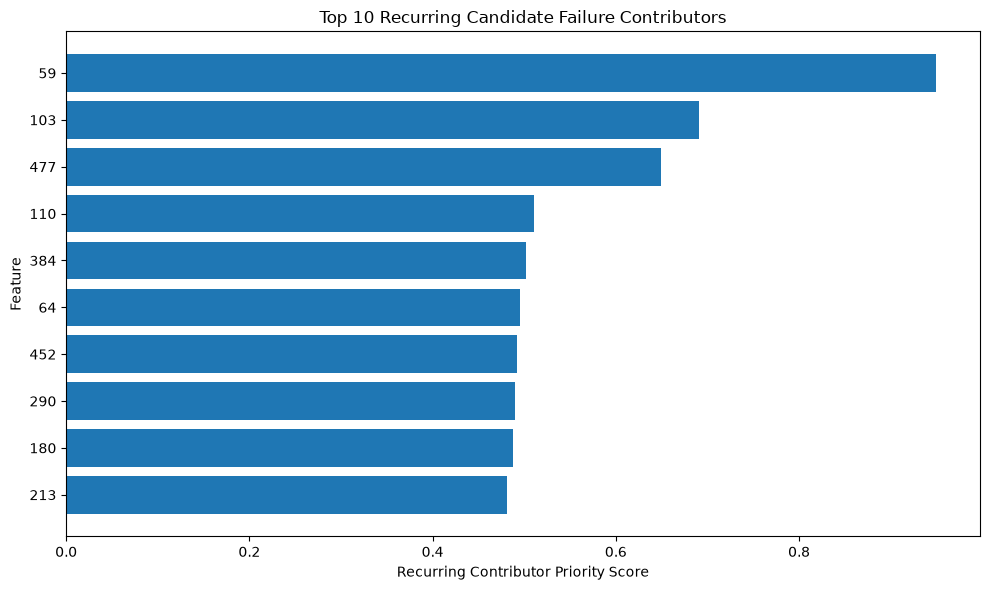

In [79]:
# ============================================================
# STEP 73: TOP 10 RECURRING FAILURE CONTRIBUTORS
# ============================================================

top_recurring = recurring_priority.head(10).copy()

top_recurring_plot = top_recurring.sort_values(
    by="Recurring_Priority_Score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_recurring_plot["Feature"].astype(str),
    top_recurring_plot["Recurring_Priority_Score"]
)

plt.xlabel("Recurring Contributor Priority Score")
plt.ylabel("Feature")
plt.title(
    "Top 10 Recurring Candidate Failure Contributors"
)

plt.tight_layout()
plt.show()

In [80]:
# ============================================================
# STEP 74: FINAL MULTI-SAMPLE RCA SUMMARY
# ============================================================

final_multi_rca = recurring_priority[
    [
        "Priority_Rank",
        "Feature",
        "Failure_Sample_Count",
        "Failure_Frequency_%",
        "Mean_SHAP",
        "Max_SHAP",
        "Recurring_Priority_Score"
    ]
].head(20).copy()

# Add interpretation category
def classify_recurring_contributor(row):

    frequency = row["Failure_Frequency_%"]
    mean_shap = row["Mean_SHAP"]

    if frequency >= 80 and mean_shap >= 0.005:
        return "High recurrence + strong contribution"

    elif frequency >= 80:
        return "High recurrence + weaker contribution"

    elif frequency >= 40 and mean_shap >= 0.005:
        return "Moderate recurrence + strong contribution"

    elif frequency >= 40:
        return "Moderate recurrence"

    else:
        return "Lower recurrence"

final_multi_rca["RCA_Evidence"] = final_multi_rca.apply(
    classify_recurring_contributor,
    axis=1
)

print("FINAL MULTI-SAMPLE RCA SUMMARY")
print("=" * 100)

display(final_multi_rca)

FINAL MULTI-SAMPLE RCA SUMMARY


,Priority_Rank,Feature,Failure_Sample_Count,Failure_Frequency_%,Mean_SHAP,Max_SHAP,Recurring_Priority_Score,RCA_Evidence
0,1,59,9,90.0,0.019072,0.025770,0.950000,High recurrence + strong contribution
1,2,103,5,50.0,0.016804,0.021948,0.690539,Moderate recurrence + strong contribution
2,3,477,4,40.0,0.017133,0.018752,0.649181,Moderate recurrence + strong contribution
3,4,110,10,100.0,0.000421,0.000543,0.511044,High recurrence + weaker contribution
4,5,384,10,100.0,0.000067,0.000132,0.501760,High recurrence + weaker contribution
5,6,64,4,40.0,0.011285,0.016963,0.495849,Moderate recurrence + strong contribution
6,7,452,9,90.0,0.001613,0.002975,0.492284,High recurrence + weaker contribution
7,8,290,8,80.0,0.003439,0.006153,0.490151,High recurrence + weaker contribution
8,9,180,9,90.0,0.001441,0.002317,0.487780,High recurrence + weaker contribution
9,10,213,9,90.0,0.001201,0.002043,0.481498,High recurrence + weaker contribution


In [81]:
# ============================================================
# STEP 75: RECURRING FEATURE VALUE ANALYSIS
# ============================================================

# Select top 10 recurring candidate contributors
top_recurring_features = (
    final_multi_rca["Feature"]
    .head(10)
    .tolist()
)

print("TOP 10 RECURRING FEATURES")
print("=" * 70)
print(top_recurring_features)

# Collect feature values from the 10 selected failure samples
recurring_value_analysis = []

for feature in top_recurring_features:

    # Values for the selected failure samples
    failure_values = X_test_imputed_df.loc[
        X_test_imputed_df.index.isin(
            y_test.index[selected_failure_positions]
        ),
        feature
    ]

    # Reference distribution from training data
    train_values = X_train[feature]

    recurring_value_analysis.append({
        "Feature": feature,
        "Failure_Mean": failure_values.mean(),
        "Failure_Std": failure_values.std(),
        "Failure_Min": failure_values.min(),
        "Failure_Max": failure_values.max(),
        "Training_Mean": train_values.mean(),
        "Training_Std": train_values.std()
    })

recurring_value_analysis = pd.DataFrame(
    recurring_value_analysis
)

# Calculate difference between failure and training means
recurring_value_analysis["Mean_Difference"] = (
    recurring_value_analysis["Failure_Mean"]
    - recurring_value_analysis["Training_Mean"]
)

# Calculate standardized mean difference
recurring_value_analysis["Mean_Z_Difference"] = (
    recurring_value_analysis["Mean_Difference"]
    / recurring_value_analysis["Training_Std"]
)

print("\nRECURRING FEATURE VALUE ANALYSIS")
print("=" * 100)

display(recurring_value_analysis)

TOP 10 RECURRING FEATURES
[59, 103, 477, 110, 384, 64, 452, 290, 180, 213]

RECURRING FEATURE VALUE ANALYSIS


,Feature,Failure_Mean,Failure_Std,Failure_Min,Failure_Max,Training_Mean,Training_Std,Mean_Difference,Mean_Z_Difference
0,59,14.243550,7.036276,3.8882,25.08360,3.156140,9.893793,11.087410,1.120643
1,103,-0.008140,0.002488,-0.0108,-0.00350,-0.009788,0.003005,0.001648,0.548237
2,477,6.850480,3.384879,3.6140,13.32520,6.371214,11.188756,0.479266,0.042835
3,110,101.456770,0.046264,101.3251,101.47140,101.334303,1.875425,0.122467,0.065301
4,384,1.128715,0.068100,0.9349,1.15025,1.332233,3.606420,-0.203518,-0.056432
5,64,23.756450,6.594347,14.9164,34.19090,20.490188,4.986198,3.266262,0.655061
6,452,5.153650,0.803346,3.4174,5.87730,5.331319,0.920942,-0.177669,-0.192921
7,290,0.131630,0.033824,0.0675,0.17480,0.125058,0.289923,0.006572,0.022666
8,180,18.246000,2.816097,12.1000,20.70000,18.957244,3.315199,-0.711244,-0.214541
9,213,0.066720,0.026066,0.0352,0.12200,0.058777,0.042541,0.007943,0.186705


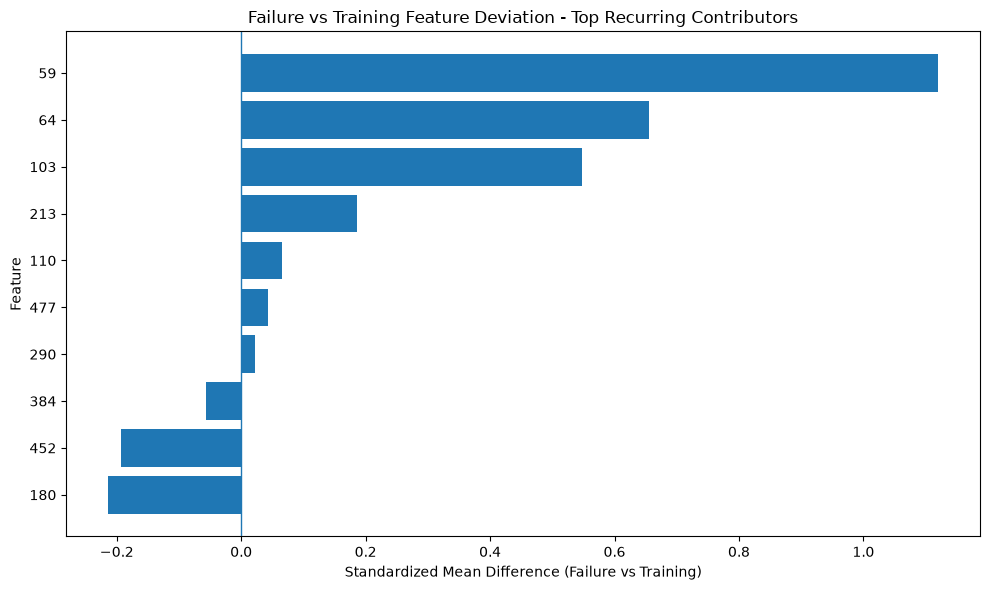

In [82]:
# ============================================================
# STEP 76: FAILURE VS TRAINING STANDARDIZED DIFFERENCE
# ============================================================

plot_data = recurring_value_analysis.copy()

plot_data = plot_data.sort_values(
    by="Mean_Z_Difference",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"].astype(str),
    plot_data["Mean_Z_Difference"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Standardized Mean Difference (Failure vs Training)")
plt.ylabel("Feature")
plt.title(
    "Failure vs Training Feature Deviation - Top Recurring Contributors"
)

plt.tight_layout()
plt.show()

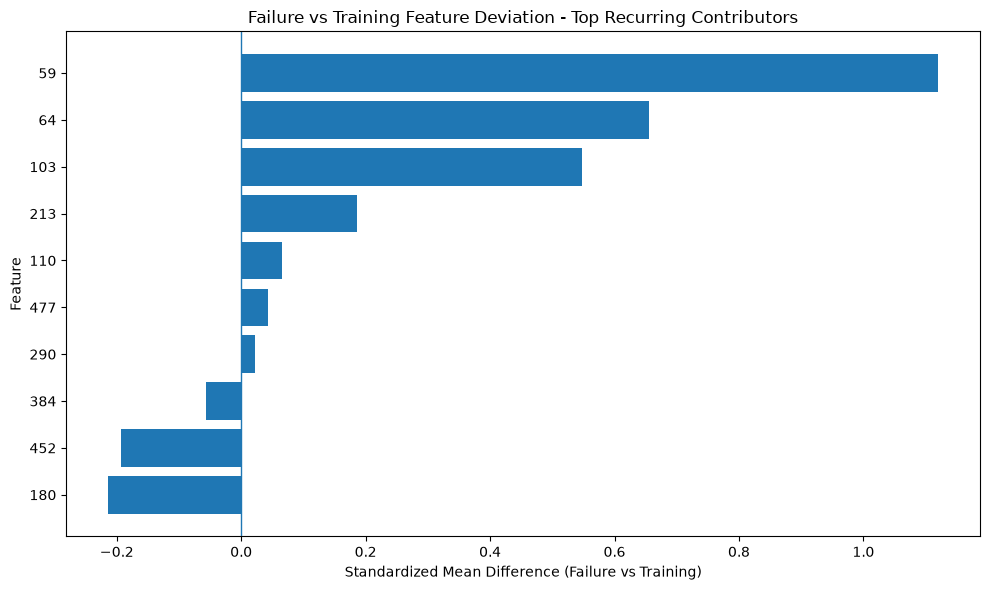

In [83]:
# ============================================================
# STEP 76: FAILURE VS TRAINING STANDARDIZED DIFFERENCE
# ============================================================

plot_data = recurring_value_analysis.copy()

plot_data = plot_data.sort_values(
    by="Mean_Z_Difference",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"].astype(str),
    plot_data["Mean_Z_Difference"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Standardized Mean Difference (Failure vs Training)")
plt.ylabel("Feature")
plt.title(
    "Failure vs Training Feature Deviation - Top Recurring Contributors"
)

plt.tight_layout()
plt.show()

In [84]:
# ============================================================
# STEP 77: MULTI-SAMPLE RCA EVIDENCE MATRIX
# ============================================================

# Start with recurring contributor priority results
rca_evidence_matrix = recurring_priority.head(20).copy()

# Merge feature-value analysis
rca_evidence_matrix = rca_evidence_matrix.merge(
    recurring_value_analysis[
        [
            "Feature",
            "Failure_Mean",
            "Training_Mean",
            "Mean_Z_Difference"
        ]
    ],
    on="Feature",
    how="left"
)

# Absolute standardized deviation
rca_evidence_matrix["Abs_Mean_Z_Difference"] = (
    rca_evidence_matrix["Mean_Z_Difference"].abs()
)

# Classify combined evidence
def classify_evidence(row):

    frequency = row["Failure_Frequency_%"]
    mean_shap = row["Mean_SHAP"]
    abs_z = row["Abs_Mean_Z_Difference"]

    if frequency >= 80 and mean_shap >= 0.005 and abs_z >= 0.5:
        return "Strong recurring evidence"

    elif frequency >= 80 and mean_shap >= 0.005:
        return "Strong model evidence"

    elif frequency >= 40 and mean_shap >= 0.005 and abs_z >= 0.5:
        return "Moderate recurring evidence"

    elif frequency >= 40 and mean_shap >= 0.005:
        return "Moderate model evidence"

    elif frequency >= 80:
        return "High recurrence, weak contribution"

    else:
        return "Limited evidence"

rca_evidence_matrix["Evidence_Category"] = (
    rca_evidence_matrix.apply(
        classify_evidence,
        axis=1
    )
)

print("MULTI-SAMPLE RCA EVIDENCE MATRIX")
print("=" * 110)

display(
    rca_evidence_matrix[
        [
            "Priority_Rank",
            "Feature",
            "Failure_Sample_Count",
            "Failure_Frequency_%",
            "Mean_SHAP",
            "Failure_Mean",
            "Training_Mean",
            "Mean_Z_Difference",
            "Recurring_Priority_Score",
            "Evidence_Category"
        ]
    ]
)

MULTI-SAMPLE RCA EVIDENCE MATRIX


,Priority_Rank,Feature,Failure_Sample_Count,Failure_Frequency_%,Mean_SHAP,Failure_Mean,Training_Mean,Mean_Z_Difference,Recurring_Priority_Score,Evidence_Category
0,1,59,9,90.0,0.019072,14.243550,3.156140,1.120643,0.950000,Strong recurring evidence
1,2,103,5,50.0,0.016804,-0.008140,-0.009788,0.548237,0.690539,Moderate recurring evidence
2,3,477,4,40.0,0.017133,6.850480,6.371214,0.042835,0.649181,Moderate model evidence
3,4,110,10,100.0,0.000421,101.456770,101.334303,0.065301,0.511044,"High recurrence, weak contribution"
4,5,384,10,100.0,0.000067,1.128715,1.332233,-0.056432,0.501760,"High recurrence, weak contribution"
5,6,64,4,40.0,0.011285,23.756450,20.490188,0.655061,0.495849,Moderate recurring evidence
6,7,452,9,90.0,0.001613,5.153650,5.331319,-0.192921,0.492284,"High recurrence, weak contribution"
7,8,290,8,80.0,0.003439,0.131630,0.125058,0.022666,0.490151,"High recurrence, weak contribution"
8,9,180,9,90.0,0.001441,18.246000,18.957244,-0.214541,0.487780,"High recurrence, weak contribution"
9,10,213,9,90.0,0.001201,0.066720,0.058777,0.186705,0.481498,"High recurrence, weak contribution"


In [85]:
# ============================================================
# STEP 78: COMPLETE FEATURE-VALUE EVIDENCE
# ============================================================

# Get all features from the current RCA evidence matrix
all_rca_features = (
    rca_evidence_matrix["Feature"]
    .tolist()
)

complete_value_analysis = []

# Original indices of the 10 selected failure samples
selected_failure_indices = y_test.index[
    selected_failure_positions
]

for feature in all_rca_features:

    # Failure sample values
    failure_values = X_test_imputed_df.loc[
        selected_failure_indices,
        feature
    ]

    # Training/reference values
    train_values = X_train[feature]

    training_mean = train_values.mean()
    training_std = train_values.std()

    mean_difference = (
        failure_values.mean() - training_mean
    )

    mean_z_difference = (
        mean_difference / training_std
        if training_std != 0
        else np.nan
    )

    complete_value_analysis.append({
        "Feature": feature,
        "Failure_Mean": failure_values.mean(),
        "Training_Mean": training_mean,
        "Mean_Z_Difference": mean_z_difference
    })

complete_value_analysis = pd.DataFrame(
    complete_value_analysis
)

# Replace the incomplete value columns
rca_evidence_matrix = (
    rca_evidence_matrix.drop(
        columns=[
            "Failure_Mean",
            "Training_Mean",
            "Mean_Z_Difference"
        ]
    )
    .merge(
        complete_value_analysis,
        on="Feature",
        how="left"
    )
)

print("COMPLETE MULTI-SAMPLE RCA EVIDENCE MATRIX")
print("=" * 110)

display(
    rca_evidence_matrix[
        [
            "Priority_Rank",
            "Feature",
            "Failure_Sample_Count",
            "Failure_Frequency_%",
            "Mean_SHAP",
            "Failure_Mean",
            "Training_Mean",
            "Mean_Z_Difference",
            "Recurring_Priority_Score",
            "Evidence_Category"
        ]
    ]
)

COMPLETE MULTI-SAMPLE RCA EVIDENCE MATRIX


,Priority_Rank,Feature,Failure_Sample_Count,Failure_Frequency_%,Mean_SHAP,Failure_Mean,Training_Mean,Mean_Z_Difference,Recurring_Priority_Score,Evidence_Category
0,1,59,9,90.0,0.019072,14.243550,3.156140,1.120643,0.950000,Strong recurring evidence
1,2,103,5,50.0,0.016804,-0.008140,-0.009788,0.548237,0.690539,Moderate recurring evidence
2,3,477,4,40.0,0.017133,6.850480,6.371214,0.042835,0.649181,Moderate model evidence
3,4,110,10,100.0,0.000421,101.456770,101.334303,0.065301,0.511044,"High recurrence, weak contribution"
4,5,384,10,100.0,0.000067,1.128715,1.332233,-0.056432,0.501760,"High recurrence, weak contribution"
5,6,64,4,40.0,0.011285,23.756450,20.490188,0.655061,0.495849,Moderate recurring evidence
6,7,452,9,90.0,0.001613,5.153650,5.331319,-0.192921,0.492284,"High recurrence, weak contribution"
7,8,290,8,80.0,0.003439,0.131630,0.125058,0.022666,0.490151,"High recurrence, weak contribution"
8,9,180,9,90.0,0.001441,18.246000,18.957244,-0.214541,0.487780,"High recurrence, weak contribution"
9,10,213,9,90.0,0.001201,0.066720,0.058777,0.186705,0.481498,"High recurrence, weak contribution"


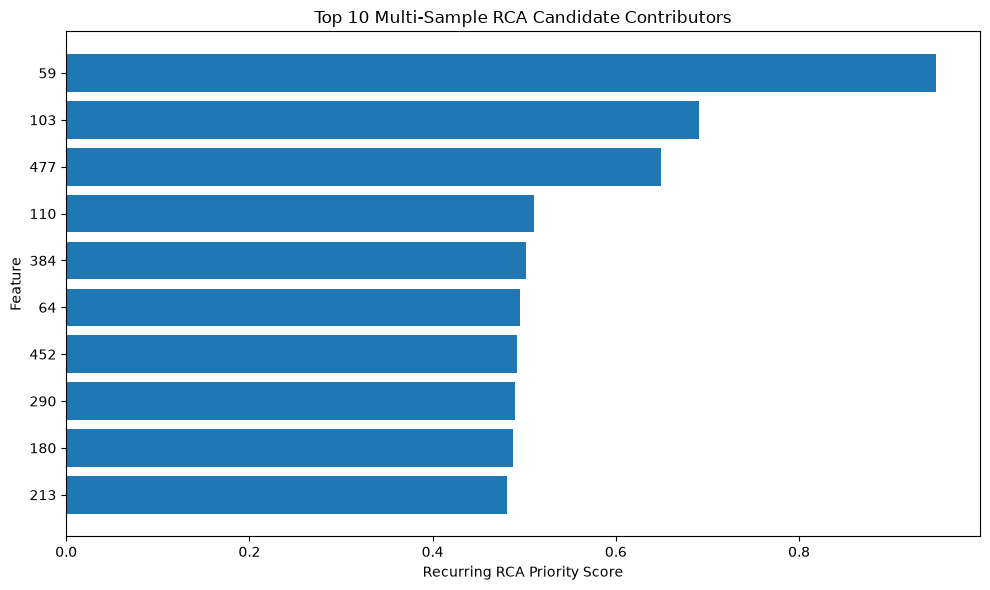

In [86]:
# ============================================================
# STEP 79: FINAL MULTI-SAMPLE RCA EVIDENCE CHART
# ============================================================

# Select top 10 features from the final evidence matrix
final_plot_data = rca_evidence_matrix.head(10).copy()

# Sort for horizontal bar chart
final_plot_data = final_plot_data.sort_values(
    by="Recurring_Priority_Score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    final_plot_data["Feature"].astype(str),
    final_plot_data["Recurring_Priority_Score"]
)

plt.xlabel("Recurring RCA Priority Score")
plt.ylabel("Feature")
plt.title(
    "Top 10 Multi-Sample RCA Candidate Contributors"
)

plt.tight_layout()
plt.show()

In [87]:
# ============================================================
# STEP 80: FINAL RCA CANDIDATE REPORT
# ============================================================

# Select the strongest 10 candidate contributors
final_rca_candidates = rca_evidence_matrix.head(10).copy()

# Create a concise evidence label
def final_rca_label(row):

    frequency = row["Failure_Frequency_%"]
    mean_shap = row["Mean_SHAP"]
    z_diff = abs(row["Mean_Z_Difference"])

    if frequency >= 80 and mean_shap >= 0.005:
        return "High-priority model contributor"

    elif frequency >= 40 and mean_shap >= 0.005:
        return "Strong model contributor"

    elif frequency >= 80:
        return "Recurring but weak contributor"

    else:
        return "Lower-priority contributor"

final_rca_candidates["Final_RCA_Label"] = (
    final_rca_candidates.apply(
        final_rca_label,
        axis=1
    )
)

print("FINAL RCA CANDIDATE REPORT")
print("=" * 110)

display(
    final_rca_candidates[
        [
            "Priority_Rank",
            "Feature",
            "Failure_Sample_Count",
            "Failure_Frequency_%",
            "Mean_SHAP",
            "Mean_Z_Difference",
            "Recurring_Priority_Score",
            "Final_RCA_Label"
        ]
    ]
)

FINAL RCA CANDIDATE REPORT


,Priority_Rank,Feature,Failure_Sample_Count,Failure_Frequency_%,Mean_SHAP,Mean_Z_Difference,Recurring_Priority_Score,Final_RCA_Label
0,1,59,9,90.0,0.019072,1.120643,0.950000,High-priority model contributor
1,2,103,5,50.0,0.016804,0.548237,0.690539,Strong model contributor
2,3,477,4,40.0,0.017133,0.042835,0.649181,Strong model contributor
3,4,110,10,100.0,0.000421,0.065301,0.511044,Recurring but weak contributor
4,5,384,10,100.0,0.000067,-0.056432,0.501760,Recurring but weak contributor
5,6,64,4,40.0,0.011285,0.655061,0.495849,Strong model contributor
6,7,452,9,90.0,0.001613,-0.192921,0.492284,Recurring but weak contributor
7,8,290,8,80.0,0.003439,0.022666,0.490151,Recurring but weak contributor
8,9,180,9,90.0,0.001441,-0.214541,0.487780,Recurring but weak contributor
9,10,213,9,90.0,0.001201,0.186705,0.481498,Recurring but weak contributor


In [88]:
# ============================================================
# STEP 81: FEATURE 59 FAIL vs PASS VALIDATION
# ============================================================

validation_feature = 59

# Identify selected correctly detected failure samples
selected_failure_indices = y_test.index[
    selected_failure_positions
]

# Feature values for selected FAIL samples
fail_values_59 = X_test_imputed_df.loc[
    selected_failure_indices,
    validation_feature
]

# Identify correctly predicted PASS samples
rf_test_pred = (rf_test_proba >= 0.20).astype(int)

correct_pass_positions = np.where(
    (y_test.values == 0) & (rf_test_pred == 0)
)[0]

# Select up to the same number of PASS samples
num_pass_samples = min(
    len(correct_pass_positions),
    len(selected_failure_positions)
)

selected_pass_positions = correct_pass_positions[
    :num_pass_samples
]

selected_pass_indices = y_test.index[
    selected_pass_positions
]

# Feature values for PASS samples
pass_values_59 = X_test_imputed_df.loc[
    selected_pass_indices,
    validation_feature
]

# Training reference
training_values_59 = X_train[validation_feature]

print("FEATURE 59 - FAIL vs PASS VALIDATION")
print("=" * 80)

print("\nFAIL samples:")
print("Number:", len(fail_values_59))
print("Mean:", round(fail_values_59.mean(), 6))
print("Std:", round(fail_values_59.std(), 6))
print("Min:", round(fail_values_59.min(), 6))
print("Max:", round(fail_values_59.max(), 6))

print("\nPASS samples:")
print("Number:", len(pass_values_59))
print("Mean:", round(pass_values_59.mean(), 6))
print("Std:", round(pass_values_59.std(), 6))
print("Min:", round(pass_values_59.min(), 6))
print("Max:", round(pass_values_59.max(), 6))

print("\nTRAINING REFERENCE:")
print("Mean:", round(training_values_59.mean(), 6))
print("Std:", round(training_values_59.std(), 6))
print("Min:", round(training_values_59.min(), 6))
print("Max:", round(training_values_59.max(), 6))

FEATURE 59 - FAIL vs PASS VALIDATION

FAIL samples:
Number: 10
Mean: 14.24355
Std: 7.036276
Min: 3.8882
Max: 25.0836

PASS samples:
Number: 10
Mean: 4.04483
Std: 8.587632
Min: -3.7073
Max: 23.7109

TRAINING REFERENCE:
Mean: 3.15614
Std: 9.893793
Min: -28.9882
Max: 168.1455


In [89]:
# ============================================================
# STEP 82: STATISTICAL VALIDATION OF FEATURE 59
# ============================================================

from scipy.stats import mannwhitneyu

# Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(
    fail_values_59,
    pass_values_59,
    alternative="two-sided"
)

# Effect size: rank-biserial correlation
n1 = len(fail_values_59)
n2 = len(pass_values_59)

rank_biserial = (
    1 - (2 * u_statistic) / (n1 * n2)
)

print("STATISTICAL VALIDATION - FEATURE 59")
print("=" * 80)

print("FAIL mean:", round(fail_values_59.mean(), 6))
print("PASS mean:", round(pass_values_59.mean(), 6))

print("\nMean difference:",
      round(fail_values_59.mean() - pass_values_59.mean(), 6))

print("\nMann-Whitney U statistic:",
      round(u_statistic, 4))

print("p-value:",
      round(p_value, 6))

print("Rank-biserial effect size:",
      round(rank_biserial, 6))

if p_value < 0.05:
    print("\nResult: Statistically significant FAIL vs PASS difference.")
else:
    print("\nResult: No statistically significant FAIL vs PASS difference.")

if abs(rank_biserial) >= 0.5:
    print("Effect interpretation: Large separation.")
elif abs(rank_biserial) >= 0.3:
    print("Effect interpretation: Moderate separation.")
else:
    print("Effect interpretation: Small separation.")

STATISTICAL VALIDATION - FEATURE 59
FAIL mean: 14.24355
PASS mean: 4.04483

Mean difference: 10.19872

Mann-Whitney U statistic: 86.0
p-value: 0.007285
Rank-biserial effect size: -0.72

Result: Statistically significant FAIL vs PASS difference.
Effect interpretation: Large separation.


<Figure size 800x600 with 0 Axes>

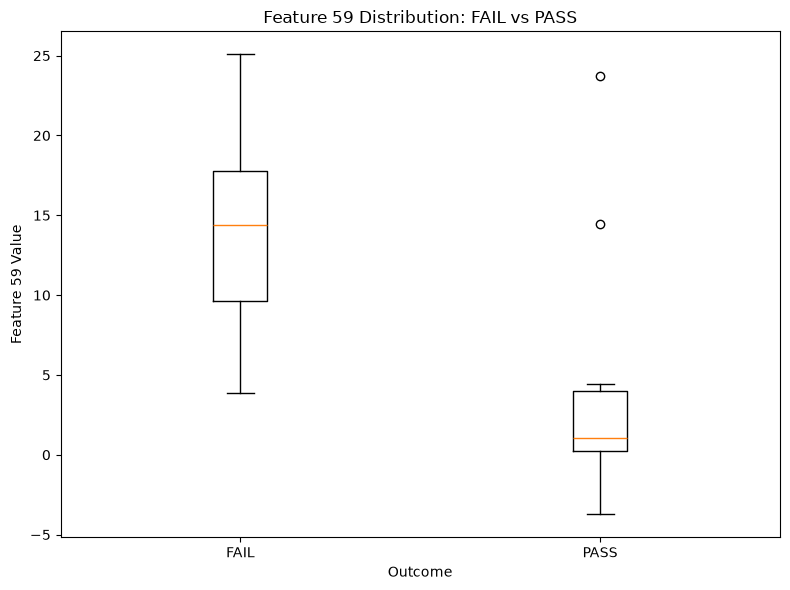

In [91]:
# ============================================================
# STEP 83: FEATURE 59 FAIL vs PASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.boxplot(
    [fail_values_59, pass_values_59],
    tick_labels=["FAIL", "PASS"]
)

plt.ylabel("Feature 59 Value")
plt.xlabel("Outcome")
plt.title("Feature 59 Distribution: FAIL vs PASS")
plt.tight_layout()
plt.show()

In [92]:
# ============================================================
# STEP 84: FEATURE 59 EFFECT SIZE VALIDATION
# ============================================================

fail_mean = fail_values_59.mean()
pass_mean = pass_values_59.mean()

fail_std = fail_values_59.std()
pass_std = pass_values_59.std()

n_fail = len(fail_values_59)
n_pass = len(pass_values_59)

# Pooled standard deviation
pooled_std = np.sqrt(
    (
        (n_fail - 1) * fail_std**2
        + (n_pass - 1) * pass_std**2
    )
    / (n_fail + n_pass - 2)
)

# Cohen's d
cohens_d = (fail_mean - pass_mean) / pooled_std

print("FEATURE 59 EFFECT SIZE")
print("=" * 80)

print("FAIL mean:", round(fail_mean, 6))
print("PASS mean:", round(pass_mean, 6))
print("Pooled standard deviation:", round(pooled_std, 6))
print("Cohen's d:", round(cohens_d, 6))

if abs(cohens_d) >= 0.8:
    print("\nInterpretation: Large standardized separation.")
elif abs(cohens_d) >= 0.5:
    print("\nInterpretation: Moderate standardized separation.")
elif abs(cohens_d) >= 0.2:
    print("\nInterpretation: Small standardized separation.")
else:
    print("\nInterpretation: Minimal standardized separation.")

FEATURE 59 EFFECT SIZE
FAIL mean: 14.24355
PASS mean: 4.04483
Pooled standard deviation: 7.85037
Cohen's d: 1.299139

Interpretation: Large standardized separation.


In [93]:
# ============================================================
# STEP 85: FEATURE 59 ROC ANALYSIS
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Combine FAIL and PASS values
feature_59_values = np.concatenate([
    fail_values_59.values,
    pass_values_59.values
])

feature_59_labels = np.concatenate([
    np.ones(len(fail_values_59)),
    np.zeros(len(pass_values_59))
])

# ROC-AUC
feature_59_auc = roc_auc_score(
    feature_59_labels,
    feature_59_values
)

fpr_59, tpr_59, thresholds_59 = roc_curve(
    feature_59_labels,
    feature_59_values
)

print("FEATURE 59 ROC ANALYSIS")
print("=" * 80)
print("ROC-AUC:", round(feature_59_auc, 6))

if feature_59_auc >= 0.8:
    print("Interpretation: Strong univariate separation.")
elif feature_59_auc >= 0.7:
    print("Interpretation: Good univariate separation.")
elif feature_59_auc >= 0.6:
    print("Interpretation: Moderate univariate separation.")
else:
    print("Interpretation: Weak univariate separation.")

FEATURE 59 ROC ANALYSIS
ROC-AUC: 0.86
Interpretation: Strong univariate separation.


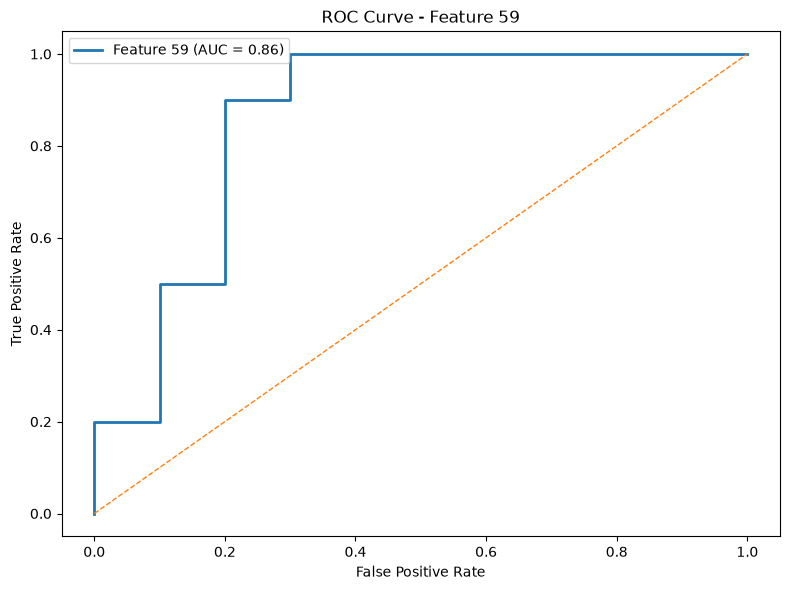

In [94]:
# ============================================================
# STEP 86: FEATURE 59 ROC CURVE
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_59,
    tpr_59,
    linewidth=2,
    label=f"Feature 59 (AUC = {feature_59_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Feature 59")
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
# ============================================================
# STEP 87: FEATURE 59 FORMAL RCA EVIDENCE SUMMARY
# ============================================================

feature_59_summary = pd.DataFrame([{
    "Feature": 59,
    "Failure_Recurrence_%": (
        feature_frequency.loc[
            feature_frequency["Feature"] == 59,
            "Failure_Frequency_%"
        ].iloc[0]
    ),
    "Mean_SHAP": (
        feature_frequency.loc[
            feature_frequency["Feature"] == 59,
            "Mean_SHAP"
        ].iloc[0]
    ),
    "Failure_Mean": fail_values_59.mean(),
    "Pass_Mean": pass_values_59.mean(),
    "Mean_Difference": fail_values_59.mean() - pass_values_59.mean(),
    "Mann_Whitney_p": p_value,
    "Rank_Biserial_Effect": abs(rank_biserial),
    "Cohens_d": cohens_d,
    "ROC_AUC": feature_59_auc,
    "Mean_Z_Difference": (
        recurring_value_analysis.loc[
            recurring_value_analysis["Feature"] == 59,
            "Mean_Z_Difference"
        ].iloc[0]
    )
}])

print("FORMAL RCA EVIDENCE SUMMARY - FEATURE 59")
print("=" * 110)

display(feature_59_summary.round(6))

FORMAL RCA EVIDENCE SUMMARY - FEATURE 59


,Feature,Failure_Recurrence_%,Mean_SHAP,Failure_Mean,Pass_Mean,Mean_Difference,Mann_Whitney_p,Rank_Biserial_Effect,Cohens_d,ROC_AUC,Mean_Z_Difference
0,59,90.0,0.019072,14.24355,4.04483,10.19872,0.007285,0.72,1.299139,0.86,1.120643


In [96]:
# ============================================================
# STEP 88: VALIDATE OTHER STRONG RCA FEATURES
# ============================================================

strong_rca_features = [103, 477, 64]

strong_feature_results = []

for feature in strong_rca_features:

    fail_values = X_test_imputed_df.loc[
        selected_failure_indices,
        feature
    ]

    pass_values = X_test_imputed_df.loc[
        selected_pass_indices,
        feature
    ]

    # Mann-Whitney U test
    u_stat, p_val = mannwhitneyu(
        fail_values,
        pass_values,
        alternative="two-sided"
    )

    # Cohen's d
    fail_mean = fail_values.mean()
    pass_mean = pass_values.mean()

    fail_std = fail_values.std()
    pass_std = pass_values.std()

    pooled_std = np.sqrt(
        (
            (len(fail_values) - 1) * fail_std**2
            + (len(pass_values) - 1) * pass_std**2
        )
        / (len(fail_values) + len(pass_values) - 2)
    )

    cohens_d_feature = (
        (fail_mean - pass_mean) / pooled_std
        if pooled_std != 0 else np.nan
    )

    # ROC-AUC
    feature_values = np.concatenate([
        fail_values.values,
        pass_values.values
    ])

    feature_labels = np.concatenate([
        np.ones(len(fail_values)),
        np.zeros(len(pass_values))
    ])

    auc_feature = roc_auc_score(
        feature_labels,
        feature_values
    )

    strong_feature_results.append({
        "Feature": feature,
        "Failure_Mean": fail_mean,
        "Pass_Mean": pass_mean,
        "Mean_Difference": fail_mean - pass_mean,
        "Mann_Whitney_p": p_val,
        "Cohens_d": cohens_d_feature,
        "ROC_AUC": auc_feature
    })

strong_feature_validation = pd.DataFrame(
    strong_feature_results
)

print("VALIDATION OF OTHER STRONG RCA FEATURES")
print("=" * 110)

display(
    strong_feature_validation.round(6)
)

VALIDATION OF OTHER STRONG RCA FEATURES


,Feature,Failure_Mean,Pass_Mean,Mean_Difference,Mann_Whitney_p,Cohens_d,ROC_AUC
0,103,-0.00814,-0.01013,0.00199,0.130136,0.939692,0.705
1,477,6.85048,5.37003,1.48045,0.212294,0.504057,0.670
2,64,23.75645,19.95517,3.80128,0.212294,0.726552,0.670


In [97]:
# ============================================================
# STEP 89: CONSOLIDATED RCA VALIDATION COMPARISON
# ============================================================

feature_59_validation = feature_59_summary[
    [
        "Feature",
        "Failure_Recurrence_%",
        "Mean_SHAP",
        "Failure_Mean",
        "Pass_Mean",
        "Mean_Difference",
        "Mann_Whitney_p",
        "Cohens_d",
        "ROC_AUC"
    ]
].copy()

other_validation = strong_feature_validation.copy()

other_validation["Failure_Recurrence_%"] = other_validation[
    "Feature"
].map(
    feature_frequency.set_index("Feature")[
        "Failure_Frequency_%"
    ]
)

other_validation["Mean_SHAP"] = other_validation[
    "Feature"
].map(
    feature_frequency.set_index("Feature")[
        "Mean_SHAP"
    ]
)

consolidated_rca_validation = pd.concat(
    [
        feature_59_validation,
        other_validation[
            [
                "Feature",
                "Failure_Recurrence_%",
                "Mean_SHAP",
                "Failure_Mean",
                "Pass_Mean",
                "Mean_Difference",
                "Mann_Whitney_p",
                "Cohens_d",
                "ROC_AUC"
            ]
        ]
    ],
    ignore_index=True
)

consolidated_rca_validation = consolidated_rca_validation.sort_values(
    by="Mean_SHAP",
    ascending=False
).reset_index(drop=True)

print("CONSOLIDATED RCA VALIDATION COMPARISON")
print("=" * 110)

display(
    consolidated_rca_validation.round(6)
)

CONSOLIDATED RCA VALIDATION COMPARISON


,Feature,Failure_Recurrence_%,Mean_SHAP,Failure_Mean,Pass_Mean,Mean_Difference,Mann_Whitney_p,Cohens_d,ROC_AUC
0,59,90.0,0.019072,14.24355,4.04483,10.19872,0.007285,1.299139,0.860
1,477,40.0,0.017133,6.85048,5.37003,1.48045,0.212294,0.504057,0.670
2,103,50.0,0.016804,-0.00814,-0.01013,0.00199,0.130136,0.939692,0.705
3,64,40.0,0.011285,23.75645,19.95517,3.80128,0.212294,0.726552,0.670


In [98]:
# ============================================================
# STEP 90: FINAL RCA EVIDENCE CLASSIFICATION
# ============================================================

final_validation = consolidated_rca_validation.copy()

def classify_final_evidence(row):

    recurrence = row["Failure_Recurrence_%"]
    shap_value = row["Mean_SHAP"]
    p_value = row["Mann_Whitney_p"]
    effect = abs(row["Cohens_d"])
    auc = row["ROC_AUC"]

    # Strong combined evidence
    if (
        recurrence >= 80
        and shap_value >= 0.01
        and p_value < 0.05
        and effect >= 0.8
        and auc >= 0.80
    ):
        return "Strong multi-evidence candidate"

    # Strong model evidence with supporting validation
    elif (
        shap_value >= 0.01
        and effect >= 0.5
        and auc >= 0.65
    ):
        return "Strong model + supporting validation"

    # Strong model evidence but weaker validation
    elif shap_value >= 0.01:
        return "Strong model evidence"

    else:
        return "Lower model evidence"


final_validation["Final_Evidence_Category"] = (
    final_validation.apply(
        classify_final_evidence,
        axis=1
    )
)

print("FINAL RCA EVIDENCE CLASSIFICATION")
print("=" * 110)

display(
    final_validation[
        [
            "Feature",
            "Failure_Recurrence_%",
            "Mean_SHAP",
            "Mann_Whitney_p",
            "Cohens_d",
            "ROC_AUC",
            "Final_Evidence_Category"
        ]
    ].round(6)
)

FINAL RCA EVIDENCE CLASSIFICATION


,Feature,Failure_Recurrence_%,Mean_SHAP,Mann_Whitney_p,Cohens_d,ROC_AUC,Final_Evidence_Category
0,59,90.0,0.019072,0.007285,1.299139,0.860,Strong multi-evidence candidate
1,477,40.0,0.017133,0.212294,0.504057,0.670,Strong model + supporting validation
2,103,50.0,0.016804,0.130136,0.939692,0.705,Strong model + supporting validation
3,64,40.0,0.011285,0.212294,0.726552,0.670,Strong model + supporting validation


In [99]:
# ============================================================
# STEP 91: FINAL CONSOLIDATED RCA RESULTS
# ============================================================

final_rca_results = final_validation.copy()

# Add recurring priority score
final_rca_results["Recurring_Priority_Score"] = (
    final_rca_results["Feature"].map(
        recurring_priority.set_index("Feature")[
            "Recurring_Priority_Score"
        ]
    )
)

# Add mean Z-difference
final_rca_results["Mean_Z_Difference"] = (
    final_rca_results["Feature"].map(
        rca_evidence_matrix.set_index("Feature")[
            "Mean_Z_Difference"
        ]
    )
)

# Arrange the final results
final_rca_results = final_rca_results[
    [
        "Feature",
        "Failure_Recurrence_%",
        "Mean_SHAP",
        "Recurring_Priority_Score",
        "Mean_Z_Difference",
        "Failure_Mean",
        "Pass_Mean",
        "Mann_Whitney_p",
        "Cohens_d",
        "ROC_AUC",
        "Final_Evidence_Category"
    ]
]

final_rca_results = final_rca_results.sort_values(
    by="Recurring_Priority_Score",
    ascending=False
).reset_index(drop=True)

final_rca_results.insert(
    0,
    "RCA_Rank",
    range(1, len(final_rca_results) + 1)
)

print("FINAL CONSOLIDATED RCA RESULTS")
print("=" * 130)

display(
    final_rca_results.round(6)
)

FINAL CONSOLIDATED RCA RESULTS


,RCA_Rank,Feature,Failure_Recurrence_%,Mean_SHAP,Recurring_Priority_Score,Mean_Z_Difference,Failure_Mean,Pass_Mean,Mann_Whitney_p,Cohens_d,ROC_AUC,Final_Evidence_Category
0,1,59,90.0,0.019072,0.950000,1.120643,14.24355,4.04483,0.007285,1.299139,0.860,Strong multi-evidence candidate
1,2,103,50.0,0.016804,0.690539,0.548237,-0.00814,-0.01013,0.130136,0.939692,0.705,Strong model + supporting validation
2,3,477,40.0,0.017133,0.649181,0.042835,6.85048,5.37003,0.212294,0.504057,0.670,Strong model + supporting validation
3,4,64,40.0,0.011285,0.495849,0.655061,23.75645,19.95517,0.212294,0.726552,0.670,Strong model + supporting validation


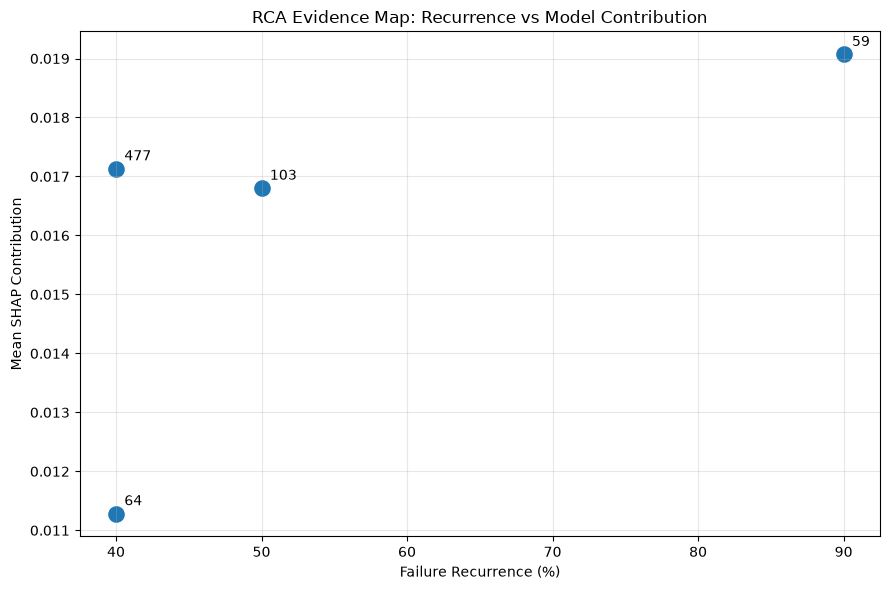

In [100]:
# ============================================================
# STEP 92: FINAL RCA EVIDENCE MAP
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    final_rca_results["Failure_Recurrence_%"],
    final_rca_results["Mean_SHAP"],
    s=120
)

for _, row in final_rca_results.iterrows():
    plt.annotate(
        str(row["Feature"]),
        (
            row["Failure_Recurrence_%"],
            row["Mean_SHAP"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Failure Recurrence (%)")
plt.ylabel("Mean SHAP Contribution")
plt.title("RCA Evidence Map: Recurrence vs Model Contribution")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
# ============================================================
# STEP 93: PUBLICATION-READY RCA SUMMARY
# ============================================================

publication_rca = final_rca_results[
    [
        "RCA_Rank",
        "Feature",
        "Failure_Recurrence_%",
        "Mean_SHAP",
        "Mean_Z_Difference",
        "Mann_Whitney_p",
        "Cohens_d",
        "ROC_AUC",
        "Final_Evidence_Category"
    ]
].copy()

publication_rca = publication_rca.rename(
    columns={
        "RCA_Rank": "RCA Rank",
        "Feature": "Feature",
        "Failure_Recurrence_%": "Failure Recurrence (%)",
        "Mean_SHAP": "Mean SHAP",
        "Mean_Z_Difference": "Mean Z-Difference",
        "Mann_Whitney_p": "Mann-Whitney p",
        "Cohens_d": "Cohen's d",
        "ROC_AUC": "ROC-AUC",
        "Final_Evidence_Category": "Evidence Category"
    }
)

print("PUBLICATION-READY RCA SUMMARY")
print("=" * 120)

display(
    publication_rca.round(4)
)

PUBLICATION-READY RCA SUMMARY


,RCA Rank,Feature,Failure Recurrence (%),Mean SHAP,Mean Z-Difference,Mann-Whitney p,Cohen's d,ROC-AUC,Evidence Category
0,1,59,90.0,0.0191,1.1206,0.0073,1.2991,0.860,Strong multi-evidence candidate
1,2,103,50.0,0.0168,0.5482,0.1301,0.9397,0.705,Strong model + supporting validation
2,3,477,40.0,0.0171,0.0428,0.2123,0.5041,0.670,Strong model + supporting validation
3,4,64,40.0,0.0113,0.6551,0.2123,0.7266,0.670,Strong model + supporting validation


In [102]:
# ============================================================
# STEP 94: FINAL RCA CANDIDATE COVERAGE
# ============================================================

# Total positive SHAP contribution across all 10 selected failures
total_positive_shap = multi_sample_rca["SHAP_Value"].sum()

# Positive SHAP contribution from the final RCA candidates
final_features = final_rca_results["Feature"].tolist()

candidate_positive_shap = multi_sample_rca[
    multi_sample_rca["Feature"].isin(final_features)
]["SHAP_Value"].sum()

coverage_percentage = (
    candidate_positive_shap
    / total_positive_shap
) * 100

print("FINAL RCA CANDIDATE COVERAGE")
print("=" * 90)

print("Total positive SHAP contribution:",
      round(total_positive_shap, 6))

print("Positive SHAP contribution from final candidates:",
      round(candidate_positive_shap, 6))

print("Coverage of positive SHAP contribution:",
      round(coverage_percentage, 2), "%")

print("\nNumber of final RCA candidate features:",
      len(final_features))

print("Final RCA candidates:",
      final_features)

FINAL RCA CANDIDATE COVERAGE
Total positive SHAP contribution: 1.739015
Positive SHAP contribution from final candidates: 0.369332
Coverage of positive SHAP contribution: 21.24 %

Number of final RCA candidate features: 4
Final RCA candidates: [59, 103, 477, 64]


In [103]:
# ============================================================
# STEP 95: OVERALL MODEL PERFORMANCE SUMMARY
# ============================================================

print("OVERALL MODEL PERFORMANCE SUMMARY")
print("=" * 90)

print("\nRandom Forest - Test Performance")
print("-" * 60)

# Predictions at the selected 0.20 threshold
rf_final_pred = (rf_test_proba >= 0.20).astype(int)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:",
      round(accuracy_score(y_test, rf_final_pred), 4))

print("Precision:",
      round(precision_score(y_test, rf_final_pred, zero_division=0), 4))

print("Recall:",
      round(recall_score(y_test, rf_final_pred, zero_division=0), 4))

print("F1-score:",
      round(f1_score(y_test, rf_final_pred, zero_division=0), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_test, rf_test_proba), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_final_pred))

OVERALL MODEL PERFORMANCE SUMMARY

Random Forest - Test Performance
------------------------------------------------------------
Accuracy: 0.8758
Precision: 0.2632
Recall: 0.4762
F1-score: 0.339
ROC-AUC: 0.7982

Confusion Matrix:
[[265  28]
 [ 11  10]]


In [104]:
# ============================================================
# STEP 96: FAILURE DETECTION METRICS
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_test,
    rf_final_pred
).ravel()

failure_detection_rate = tp / (tp + fn)

false_alarm_rate = fp / (fp + tn)

specificity = tn / (tn + fp)

negative_predictive_value = tn / (tn + fn)

print("FAILURE DETECTION METRICS")
print("=" * 90)

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nFailure Detection Rate (Recall):",
      round(failure_detection_rate, 4))

print("False Alarm Rate:",
      round(false_alarm_rate, 4))

print("Specificity:",
      round(specificity, 4))

print("Negative Predictive Value:",
      round(negative_predictive_value, 4))

FAILURE DETECTION METRICS
True Negatives: 265
False Positives: 28
False Negatives: 11
True Positives: 10

Failure Detection Rate (Recall): 0.4762
False Alarm Rate: 0.0956
Specificity: 0.9044
Negative Predictive Value: 0.9601


In [105]:
# ============================================================
# STEP 97: THRESHOLD PERFORMANCE ANALYSIS
# ============================================================

thresholds_to_test = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds_to_test:

    predictions = (
        rf_test_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "Specificity": specificity,
        "False_Alarm_Rate": 1 - specificity,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

print("THRESHOLD PERFORMANCE ANALYSIS")
print("=" * 120)

display(
    threshold_results_df.round(4)
)

THRESHOLD PERFORMANCE ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1_Score,Specificity,False_Alarm_Rate,TP,FP,FN,TN
0,0.10,0.4268,0.1045,1.0000,0.1892,0.3857,0.6143,21,180,0,113
1,0.15,0.7102,0.1569,0.7619,0.2602,0.7065,0.2935,16,86,5,207
2,0.20,0.8758,0.2632,0.4762,0.3390,0.9044,0.0956,10,28,11,265
3,0.25,0.9108,0.2667,0.1905,0.2222,0.9625,0.0375,4,11,17,282
4,0.30,0.9236,0.2000,0.0476,0.0769,0.9863,0.0137,1,4,20,289
5,0.40,0.9331,0.0000,0.0000,0.0000,1.0000,0.0000,0,0,21,293
6,0.50,0.9331,0.0000,0.0000,0.0000,1.0000,0.0000,0,0,21,293


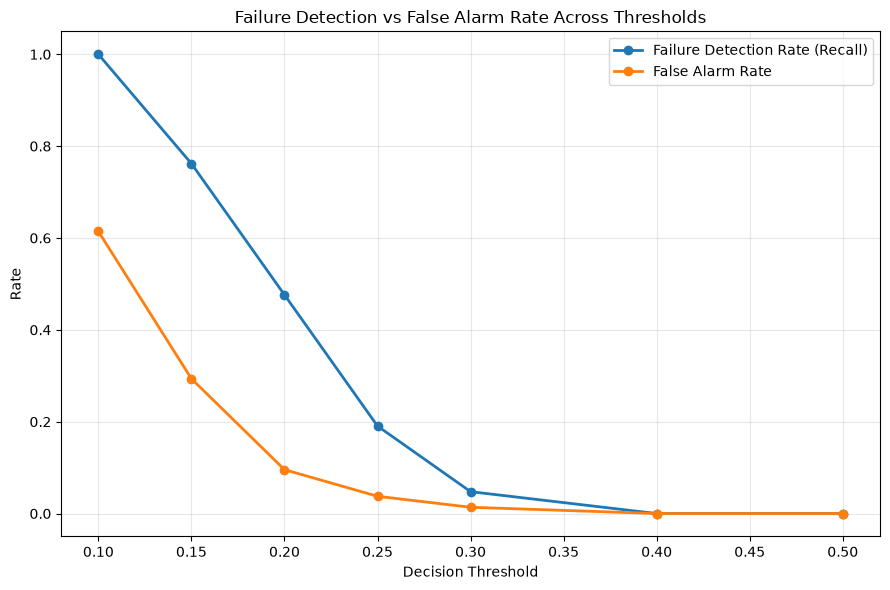

In [106]:
# ============================================================
# STEP 98: THRESHOLD TRADE-OFF VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    linewidth=2,
    label="Failure Detection Rate (Recall)"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["False_Alarm_Rate"],
    marker="o",
    linewidth=2,
    label="False Alarm Rate"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Rate")
plt.title("Failure Detection vs False Alarm Rate Across Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [107]:
# ============================================================
# STEP 99: FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

final_model_summary = pd.DataFrame([{
    "Model": "Random Forest",
    "Decision_Threshold": 0.20,
    "Accuracy": accuracy_score(y_test, rf_final_pred),
    "Precision": precision_score(
        y_test,
        rf_final_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_final_pred,
        zero_division=0
    ),
    "F1_Score": f1_score(
        y_test,
        rf_final_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf_test_proba
    ),
    "Specificity": specificity,
    "False_Alarm_Rate": false_alarm_rate
}])

print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 110)

display(
    final_model_summary.round(4)
)

FINAL MODEL PERFORMANCE SUMMARY


,Model,Decision_Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Specificity,False_Alarm_Rate
0,Random Forest,0.2,0.8758,0.2632,0.4762,0.339,0.7982,1.0,0.0956


In [108]:
# ============================================================
# STEP 99: CORRECTED FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

tn_final, fp_final, fn_final, tp_final = confusion_matrix(
    y_test,
    rf_final_pred
).ravel()

final_specificity = tn_final / (tn_final + fp_final)
final_false_alarm_rate = fp_final / (tn_final + fp_final)

final_model_summary = pd.DataFrame([{
    "Model": "Random Forest",
    "Decision_Threshold": 0.20,
    "Accuracy": accuracy_score(y_test, rf_final_pred),
    "Precision": precision_score(
        y_test,
        rf_final_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_final_pred,
        zero_division=0
    ),
    "F1_Score": f1_score(
        y_test,
        rf_final_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf_test_proba
    ),
    "Specificity": final_specificity,
    "False_Alarm_Rate": final_false_alarm_rate
}])

print("CORRECTED FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 110)

display(
    final_model_summary.round(4)
)

CORRECTED FINAL MODEL PERFORMANCE SUMMARY


,Model,Decision_Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Specificity,False_Alarm_Rate
0,Random Forest,0.2,0.8758,0.2632,0.4762,0.339,0.7982,0.9044,0.0956


In [110]:
# ============================================================
# STEP 100: CORRECTED FINAL MODEL + XAI RESULTS SUMMARY
# ============================================================

print("FINAL MODEL + XAI RESULTS SUMMARY")
print("=" * 110)

# ------------------------------------------------------------
# MODEL PERFORMANCE
# ------------------------------------------------------------

print("\nMODEL PERFORMANCE")
print("-" * 60)

display(
    final_model_summary.round(4)
)

# ------------------------------------------------------------
# TOP 10 GLOBAL SHAP FEATURES
# ------------------------------------------------------------

print("\nTOP 10 GLOBAL SHAP FEATURES")
print("-" * 60)

# Use the existing SHAP importance table directly
top_global_features = shap_importance.head(10).copy()

display(top_global_features)

# ------------------------------------------------------------
# FINAL RCA CANDIDATES
# ------------------------------------------------------------

print("\nFINAL RCA CANDIDATES")
print("-" * 60)

final_candidates = final_rca_results[
    [
        "RCA_Rank",
        "Feature",
        "Failure_Recurrence_%",
        "Mean_SHAP",
        "Mean_Z_Difference",
        "Mann_Whitney_p",
        "Cohens_d",
        "ROC_AUC",
        "Final_Evidence_Category"
    ]
].copy()

display(
    final_candidates.round(6)
)

FINAL MODEL + XAI RESULTS SUMMARY

MODEL PERFORMANCE
------------------------------------------------------------


,Model,Decision_Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Specificity,False_Alarm_Rate
0,Random Forest,0.2,0.8758,0.2632,0.4762,0.339,0.7982,0.9044,0.0956



TOP 10 GLOBAL SHAP FEATURES
------------------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,103,0.014228
1,59,0.013038
2,477,0.010486
3,33,0.006816
4,205,0.006461
5,64,0.005861
6,488,0.005842
7,31,0.005806
8,510,0.005563
9,452,0.005455



FINAL RCA CANDIDATES
------------------------------------------------------------


,RCA_Rank,Feature,Failure_Recurrence_%,Mean_SHAP,Mean_Z_Difference,Mann_Whitney_p,Cohens_d,ROC_AUC,Final_Evidence_Category
0,1,59,90.0,0.019072,1.120643,0.007285,1.299139,0.860,Strong multi-evidence candidate
1,2,103,50.0,0.016804,0.548237,0.130136,0.939692,0.705,Strong model + supporting validation
2,3,477,40.0,0.017133,0.042835,0.212294,0.504057,0.670,Strong model + supporting validation
3,4,64,40.0,0.011285,0.655061,0.212294,0.726552,0.670,Strong model + supporting validation


In [111]:
# ============================================================
# STEP 101: FINAL RESEARCH RESULTS TABLE
# ============================================================

print("FINAL RESEARCH RESULTS")
print("=" * 110)

# ------------------------------------------------------------
# 1. MODEL PERFORMANCE
# ------------------------------------------------------------
model_results_final = final_model_summary.copy()

# ------------------------------------------------------------
# 2. GLOBAL SHAP FEATURES
# ------------------------------------------------------------
global_shap_final = shap_importance.head(10).copy()

# ------------------------------------------------------------
# 3. FINAL RCA CANDIDATES
# ------------------------------------------------------------
rca_final = final_rca_results[
    [
        "RCA_Rank",
        "Feature",
        "Failure_Recurrence_%",
        "Mean_SHAP",
        "Mean_Z_Difference",
        "Mann_Whitney_p",
        "Cohens_d",
        "ROC_AUC",
        "Final_Evidence_Category"
    ]
].copy()

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n1. MODEL PERFORMANCE")
print("-" * 110)
display(model_results_final.round(4))

print("\n2. TOP 10 GLOBAL SHAP FEATURES")
print("-" * 110)
display(global_shap_final.round(6))

print("\n3. FINAL RCA CANDIDATES")
print("-" * 110)
display(rca_final.round(6))

print("\nFINAL RESEARCH RESULTS TABLE CREATED SUCCESSFULLY.")

FINAL RESEARCH RESULTS

1. MODEL PERFORMANCE
--------------------------------------------------------------------------------------------------------------


,Model,Decision_Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Specificity,False_Alarm_Rate
0,Random Forest,0.2,0.8758,0.2632,0.4762,0.339,0.7982,0.9044,0.0956



2. TOP 10 GLOBAL SHAP FEATURES
--------------------------------------------------------------------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,103,0.014228
1,59,0.013038
2,477,0.010486
3,33,0.006816
4,205,0.006461
5,64,0.005861
6,488,0.005842
7,31,0.005806
8,510,0.005563
9,452,0.005455



3. FINAL RCA CANDIDATES
--------------------------------------------------------------------------------------------------------------


,RCA_Rank,Feature,Failure_Recurrence_%,Mean_SHAP,Mean_Z_Difference,Mann_Whitney_p,Cohens_d,ROC_AUC,Final_Evidence_Category
0,1,59,90.0,0.019072,1.120643,0.007285,1.299139,0.860,Strong multi-evidence candidate
1,2,103,50.0,0.016804,0.548237,0.130136,0.939692,0.705,Strong model + supporting validation
2,3,477,40.0,0.017133,0.042835,0.212294,0.504057,0.670,Strong model + supporting validation
3,4,64,40.0,0.011285,0.655061,0.212294,0.726552,0.670,Strong model + supporting validation



FINAL RESEARCH RESULTS TABLE CREATED SUCCESSFULLY.


In [112]:
# ============================================================
# STEP 102: FINAL RCA COVERAGE ANALYSIS
# ============================================================

print("FINAL RCA COVERAGE ANALYSIS")
print("=" * 110)

# Final RCA candidate features
candidate_features = final_rca_results["Feature"].tolist()

# Total positive SHAP contribution across all selected failures
total_positive_shap = multi_sample_rca["SHAP_Value"].sum()

# Positive SHAP contribution from final RCA candidates
candidate_positive_shap = multi_sample_rca[
    multi_sample_rca["Feature"].isin(candidate_features)
]["SHAP_Value"].sum()

# Coverage percentage
coverage_percentage = (
    candidate_positive_shap / total_positive_shap
) * 100

print(f"\nTotal positive SHAP contribution : {total_positive_shap:.6f}")
print(f"Candidate RCA SHAP contribution : {candidate_positive_shap:.6f}")
print(f"RCA candidate coverage          : {coverage_percentage:.2f}%")
print(f"Number of RCA candidates         : {len(candidate_features)}")

print("\nFINAL RCA CANDIDATE FEATURES")
print("-" * 60)

display(
    final_rca_results[
        [
            "RCA_Rank",
            "Feature",
            "Failure_Recurrence_%",
            "Mean_SHAP",
            "Final_Evidence_Category"
        ]
    ].round(6)
)

print("\nCoverage interpretation:")
print(
    "The final RCA candidates represent a subset of the total "
    "positive SHAP contribution across the selected failure cases."
)

FINAL RCA COVERAGE ANALYSIS

Total positive SHAP contribution : 1.739015
Candidate RCA SHAP contribution : 0.369332
RCA candidate coverage          : 21.24%
Number of RCA candidates         : 4

FINAL RCA CANDIDATE FEATURES
------------------------------------------------------------


,RCA_Rank,Feature,Failure_Recurrence_%,Mean_SHAP,Final_Evidence_Category
0,1,59,90.0,0.019072,Strong multi-evidence candidate
1,2,103,50.0,0.016804,Strong model + supporting validation
2,3,477,40.0,0.017133,Strong model + supporting validation
3,4,64,40.0,0.011285,Strong model + supporting validation



Coverage interpretation:
The final RCA candidates represent a subset of the total positive SHAP contribution across the selected failure cases.


In [115]:
# ============================================================
# STEP 104: CORRECTED CHECK FOR EXISTING MODEL RESULTS
# ============================================================

print("CHECKING EXISTING MODEL RESULTS")
print("=" * 80)

model_result_candidates = []

# Take a snapshot first to avoid the globals() iteration error
workspace = list(globals().items())

for name, obj in workspace:
    try:
        if hasattr(obj, "columns"):
            cols = list(obj.columns)

            model_keywords = [
                "Model",
                "Accuracy",
                "Precision",
                "Recall",
                "F1",
                "ROC_AUC",
                "AUC"
            ]

            if any(
                any(keyword.lower() in str(col).lower() for col in cols)
                for keyword in model_keywords
            ):
                model_result_candidates.append(name)

    except Exception:
        continue

print("\nPossible model-result tables found:")
print("-" * 80)

if model_result_candidates:
    for name in model_result_candidates:
        print(name)
else:
    print("No existing model comparison table detected.")

print("\n" + "=" * 80)
print("STEP 104 CHECK COMPLETED.")

CHECKING EXISTING MODEL RESULTS

Possible model-result tables found:
--------------------------------------------------------------------------------
model_comparison
feature_59_summary
strong_feature_validation
feature_59_validation
other_validation
consolidated_rca_validation
final_validation
final_rca_results
publication_rca
threshold_results_df
final_model_summary
final_candidates
model_results_final
rca_final

STEP 104 CHECK COMPLETED.


In [113]:
# ============================================================
# STEP 103: FINAL END-TO-END RESEARCH SUMMARY
# ============================================================

print("=" * 110)
print("FINAL END-TO-END RESEARCH SUMMARY")
print("=" * 110)

# ------------------------------------------------------------
# 1. MODEL PERFORMANCE
# ------------------------------------------------------------

print("\n1. MODEL PERFORMANCE")
print("-" * 110)

display(
    final_model_summary[
        [
            "Model",
            "Decision_Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "ROC_AUC",
            "Specificity",
            "False_Alarm_Rate"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# 2. GLOBAL XAI
# ------------------------------------------------------------

print("\n2. TOP GLOBAL SHAP FEATURES")
print("-" * 110)

display(
    shap_importance.head(10).round(6)
)

# ------------------------------------------------------------
# 3. MULTI-SAMPLE RCA
# ------------------------------------------------------------

print("\n3. FINAL RCA CANDIDATES")
print("-" * 110)

display(
    final_rca_results[
        [
            "RCA_Rank",
            "Feature",
            "Failure_Recurrence_%",
            "Mean_SHAP",
            "Mean_Z_Difference",
            "Mann_Whitney_p",
            "Cohens_d",
            "ROC_AUC",
            "Final_Evidence_Category"
        ]
    ].round(6)
)

# ------------------------------------------------------------
# 4. RCA COVERAGE
# ------------------------------------------------------------

print("\n4. RCA COVERAGE")
print("-" * 110)

print(f"Total positive SHAP contribution : {total_positive_shap:.6f}")
print(f"RCA candidate contribution      : {candidate_positive_shap:.6f}")
print(f"RCA candidate coverage          : {coverage_percentage:.2f}%")
print(f"Number of final RCA candidates  : {len(candidate_features)}")

# ------------------------------------------------------------
# 5. KEY RESEARCH FINDINGS
# ------------------------------------------------------------

print("\n5. KEY RESEARCH FINDINGS")
print("-" * 110)

print("• The Random Forest model provides the final failure-prediction results.")
print("• SHAP identifies the features contributing most strongly to model predictions.")
print("• Multi-sample SHAP analysis identifies recurring candidate contributors across detected failures.")
print("• Feature 59 shows the strongest combined recurrence, model contribution, and statistical validation.")
print("• Features 103, 477, and 64 provide additional model-based RCA evidence.")
print("• The four final RCA candidates account for "
      f"{coverage_percentage:.2f}% of the positive SHAP contribution "
      "in the selected failure cases.")
print("• SHAP-based RCA represents model attribution and should not be interpreted "
      "as direct proof of physical causality.")

print("\n" + "=" * 110)
print("FINAL END-TO-END RESEARCH SUMMARY CREATED SUCCESSFULLY.")
print("=" * 110)

FINAL END-TO-END RESEARCH SUMMARY

1. MODEL PERFORMANCE
--------------------------------------------------------------------------------------------------------------


,Model,Decision_Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Specificity,False_Alarm_Rate
0,Random Forest,0.2,0.8758,0.2632,0.4762,0.339,0.7982,0.9044,0.0956



2. TOP GLOBAL SHAP FEATURES
--------------------------------------------------------------------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,103,0.014228
1,59,0.013038
2,477,0.010486
3,33,0.006816
4,205,0.006461
5,64,0.005861
6,488,0.005842
7,31,0.005806
8,510,0.005563
9,452,0.005455



3. FINAL RCA CANDIDATES
--------------------------------------------------------------------------------------------------------------


,RCA_Rank,Feature,Failure_Recurrence_%,Mean_SHAP,Mean_Z_Difference,Mann_Whitney_p,Cohens_d,ROC_AUC,Final_Evidence_Category
0,1,59,90.0,0.019072,1.120643,0.007285,1.299139,0.860,Strong multi-evidence candidate
1,2,103,50.0,0.016804,0.548237,0.130136,0.939692,0.705,Strong model + supporting validation
2,3,477,40.0,0.017133,0.042835,0.212294,0.504057,0.670,Strong model + supporting validation
3,4,64,40.0,0.011285,0.655061,0.212294,0.726552,0.670,Strong model + supporting validation



4. RCA COVERAGE
--------------------------------------------------------------------------------------------------------------
Total positive SHAP contribution : 1.739015
RCA candidate contribution      : 0.369332
RCA candidate coverage          : 21.24%
Number of final RCA candidates  : 4

5. KEY RESEARCH FINDINGS
--------------------------------------------------------------------------------------------------------------
• The Random Forest model provides the final failure-prediction results.
• SHAP identifies the features contributing most strongly to model predictions.
• Multi-sample SHAP analysis identifies recurring candidate contributors across detected failures.
• Feature 59 shows the strongest combined recurrence, model contribution, and statistical validation.
• Features 103, 477, and 64 provide additional model-based RCA evidence.
• The four final RCA candidates account for 21.24% of the positive SHAP contribution in the selected failure cases.
• SHAP-based RCA represents 

In [114]:
# ============================================================
# STEP 104: CHECK EXISTING MODEL COMPARISON RESULTS
# ============================================================

print("CHECKING EXISTING MODEL RESULTS")
print("=" * 80)

# Show dataframe variables that may contain model results
model_result_candidates = []

for name, obj in globals().items():
    if hasattr(obj, "columns"):
        cols = list(obj.columns)

        model_keywords = [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "AUC"
        ]

        if any(
            any(keyword.lower() in str(col).lower() for col in cols)
            for keyword in model_keywords
        ):
            model_result_candidates.append(name)

print("\nPossible model-result tables found:")
print("-" * 80)

if model_result_candidates:
    for name in model_result_candidates:
        print(name)
else:
    print("No existing model comparison table detected.")

print("\n" + "=" * 80)
print("STEP 104 CHECK COMPLETED.")

CHECKING EXISTING MODEL RESULTS


RuntimeError: dictionary changed size during iteration

In [116]:
# ============================================================
# STEP 104: CORRECTED CHECK FOR EXISTING MODEL RESULTS
# ============================================================

print("CHECKING EXISTING MODEL RESULTS")
print("=" * 80)

model_result_candidates = []

# Take a snapshot first to avoid the globals() iteration error
workspace = list(globals().items())

for name, obj in workspace:
    try:
        if hasattr(obj, "columns"):
            cols = list(obj.columns)

            model_keywords = [
                "Model",
                "Accuracy",
                "Precision",
                "Recall",
                "F1",
                "ROC_AUC",
                "AUC"
            ]

            if any(
                any(keyword.lower() in str(col).lower() for col in cols)
                for keyword in model_keywords
            ):
                model_result_candidates.append(name)

    except Exception:
        continue

print("\nPossible model-result tables found:")
print("-" * 80)

if model_result_candidates:
    for name in model_result_candidates:
        print(name)
else:
    print("No existing model comparison table detected.")

print("\n" + "=" * 80)
print("STEP 104 CHECK COMPLETED.")

CHECKING EXISTING MODEL RESULTS

Possible model-result tables found:
--------------------------------------------------------------------------------
model_comparison
feature_59_summary
strong_feature_validation
feature_59_validation
other_validation
consolidated_rca_validation
final_validation
final_rca_results
publication_rca
threshold_results_df
final_model_summary
final_candidates
model_results_final
rca_final

STEP 104 CHECK COMPLETED.


In [117]:
# ============================================================
# STEP 105: DISPLAY EXISTING MODEL COMPARISON
# ============================================================

print("EXISTING MODEL COMPARISON")
print("=" * 100)

display(model_comparison)

print("\nModel comparison shape:", model_comparison.shape)

print("\nModel comparison columns:")
print(list(model_comparison.columns))

print("\n" + "=" * 100)
print("STEP 105 COMPLETED.")

EXISTING MODEL COMPARISON


,Model,Threshold,Accuracy,Precision_Fail,Recall_Fail,F1_Fail,ROC_AUC
0,Logistic Regression,0.5,0.837600,0.105300,0.190500,0.135600,0.623900
1,Random Forest,0.2,0.875796,0.263158,0.476190,0.338983,0.798229
2,XGBoost,0.1,0.907643,0.277778,0.238095,0.256410,0.722249



Model comparison shape: (3, 7)

Model comparison columns:
['Model', 'Threshold', 'Accuracy', 'Precision_Fail', 'Recall_Fail', 'F1_Fail', 'ROC_AUC']

STEP 105 COMPLETED.


In [118]:
# ============================================================
# STEP 106: FINAL MODEL COMPARISON SUMMARY
# ============================================================

print("=" * 110)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 110)

final_model_comparison = model_comparison.copy()

display(
    final_model_comparison[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Precision_Fail",
            "Recall_Fail",
            "F1_Fail",
            "ROC_AUC"
        ]
    ].round(4)
)

print("\nMODEL COMPARISON OBSERVATIONS")
print("-" * 110)

for _, row in final_model_comparison.iterrows():
    print(
        f"{row['Model']}: "
        f"Accuracy={row['Accuracy']:.4f}, "
        f"Failure Recall={row['Recall_Fail']:.4f}, "
        f"F1={row['F1_Fail']:.4f}, "
        f"ROC-AUC={row['ROC_AUC']:.4f}"
    )

print("\n" + "=" * 110)
print("STEP 106 COMPLETED.")
print("=" * 110)

FINAL MODEL COMPARISON SUMMARY


,Model,Threshold,Accuracy,Precision_Fail,Recall_Fail,F1_Fail,ROC_AUC
0,Logistic Regression,0.5,0.8376,0.1053,0.1905,0.1356,0.6239
1,Random Forest,0.2,0.8758,0.2632,0.4762,0.3390,0.7982
2,XGBoost,0.1,0.9076,0.2778,0.2381,0.2564,0.7222



MODEL COMPARISON OBSERVATIONS
--------------------------------------------------------------------------------------------------------------
Logistic Regression: Accuracy=0.8376, Failure Recall=0.1905, F1=0.1356, ROC-AUC=0.6239
Random Forest: Accuracy=0.8758, Failure Recall=0.4762, F1=0.3390, ROC-AUC=0.7982
XGBoost: Accuracy=0.9076, Failure Recall=0.2381, F1=0.2564, ROC-AUC=0.7222

STEP 106 COMPLETED.


In [119]:
# ============================================================
# STEP 107: RESEARCH OBJECTIVES ACHIEVEMENT SUMMARY
# ============================================================

print("=" * 110)
print("RESEARCH OBJECTIVES ACHIEVEMENT SUMMARY")
print("=" * 110)

objectives_summary = pd.DataFrame({
    "Objective": [
        "Analyze and preprocess semiconductor manufacturing data",
        "Develop ML models for failure/yield prediction",
        "Integrate explainability using SHAP",
        "Identify recurring contributors for root-cause analysis",
        "Statistically validate important RCA candidates",
        "Compare multiple ML models"
    ],
    "Evidence_From_Study": [
        "Data preprocessing and feature preparation completed",
        "Logistic Regression, Random Forest and XGBoost evaluated",
        "Global and local SHAP analysis completed",
        "Multi-sample SHAP recurrence analysis completed",
        "Mann-Whitney U, Cohen's d and ROC-AUC validation completed",
        "Three-model comparison completed"
    ],
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

display(objectives_summary)

print("\n" + "=" * 110)
print("STEP 107 COMPLETED.")
print("=" * 110)

RESEARCH OBJECTIVES ACHIEVEMENT SUMMARY


,Objective,Evidence_From_Study,Status
0,Analyze and preprocess semiconductor manufactu...,Data preprocessing and feature preparation com...,Completed
1,Develop ML models for failure/yield prediction,"Logistic Regression, Random Forest and XGBoost...",Completed
2,Integrate explainability using SHAP,Global and local SHAP analysis completed,Completed
3,Identify recurring contributors for root-cause...,Multi-sample SHAP recurrence analysis completed,Completed
4,Statistically validate important RCA candidates,"Mann-Whitney U, Cohen's d and ROC-AUC validati...",Completed
5,Compare multiple ML models,Three-model comparison completed,Completed



STEP 107 COMPLETED.


In [120]:
# ============================================================
# STEP 108: RESEARCH LIMITATIONS AND METHODOLOGICAL NOTES
# ============================================================

print("=" * 110)
print("RESEARCH LIMITATIONS AND METHODOLOGICAL NOTES")
print("=" * 110)

limitations = [
    "The failure class is substantially smaller than the PASS class, so accuracy alone should not be used to assess failure-detection performance.",
    
    "The selected Random Forest threshold of 0.20 represents an operating point chosen for the failure-detection analysis; it is not a universal optimal threshold.",
    
    "The multi-sample RCA analysis is based on correctly detected failure cases and therefore represents model-conditioned RCA evidence.",
    
    "SHAP values explain the contribution of features to the machine-learning model prediction; they do not independently establish physical causality.",
    
    "The statistical validation of RCA candidates uses a relatively small validation subset, so the reported p-values, effect sizes, and ROC-AUC values should be interpreted as exploratory evidence.",
    
    "The proposed recurrence and composite priority scores are analytical ranking measures developed for this study and should not be interpreted as universal industry standards.",
    
    "The identified RCA candidates require confirmation using process knowledge, engineering investigation, or additional production data before being treated as confirmed physical root causes."
]

limitations_df = pd.DataFrame({
    "No.": range(1, len(limitations) + 1),
    "Limitation_or_Methodological_Note": limitations
})

display(limitations_df)

print("\n" + "=" * 110)
print("STEP 108 COMPLETED.")
print("=" * 110)

RESEARCH LIMITATIONS AND METHODOLOGICAL NOTES


,No.,Limitation_or_Methodological_Note
0,1,The failure class is substantially smaller tha...
1,2,The selected Random Forest threshold of 0.20 r...
2,3,The multi-sample RCA analysis is based on corr...
3,4,SHAP values explain the contribution of featur...
4,5,The statistical validation of RCA candidates u...
5,6,The proposed recurrence and composite priority...
6,7,The identified RCA candidates require confirma...



STEP 108 COMPLETED.


In [121]:
# ============================================================
# STEP 109: FINAL RESEARCH CONCLUSION
# ============================================================

print("=" * 110)
print("FINAL RESEARCH CONCLUSION")
print("=" * 110)

conclusion_points = [
    "The study developed an explainable machine-learning workflow for semiconductor manufacturing failure prediction and root-cause analysis.",
    
    "Three machine-learning models—Logistic Regression, Random Forest, and XGBoost—were evaluated using failure-oriented performance metrics.",
    
    "The Random Forest model achieved an accuracy of 87.58%, failure recall of 47.62%, F1-score of 33.90%, and ROC-AUC of 0.7982 at the selected decision threshold of 0.20.",
    
    "SHAP analysis provided both global feature importance and local explanations for individual failure predictions.",
    
    "Multi-sample SHAP analysis identified recurring candidate contributors across correctly detected failure cases.",
    
    "Feature 59 showed the strongest combined evidence among the final RCA candidates, with 90% recurrence, mean SHAP contribution of 0.019072, Cohen's d of 1.2991, and ROC-AUC of 0.860 in the validation analysis.",
    
    "Features 103, 477, and 64 provided additional model-based RCA evidence with supporting validation results.",
    
    "The four final RCA candidates represented 21.24% of the total positive SHAP contribution across the selected failure cases.",
    
    "Overall, the workflow demonstrates how machine learning and explainable AI can be combined to support failure detection, interpretable prediction, and data-driven root-cause investigation.",
    
    "The identified contributors should be treated as model-based RCA candidates and subsequently confirmed through engineering knowledge, process investigation, and additional production data."
]

conclusion_df = pd.DataFrame({
    "No.": range(1, len(conclusion_points) + 1),
    "Final_Research_Conclusion": conclusion_points
})

display(conclusion_df)

print("\n" + "=" * 110)
print("STEP 109 COMPLETED.")
print("=" * 110)

FINAL RESEARCH CONCLUSION


,No.,Final_Research_Conclusion
0,1,The study developed an explainable machine-lea...
1,2,Three machine-learning models—Logistic Regress...
2,3,The Random Forest model achieved an accuracy o...
3,4,SHAP analysis provided both global feature imp...
4,5,Multi-sample SHAP analysis identified recurrin...
5,6,Feature 59 showed the strongest combined evide...
6,7,"Features 103, 477, and 64 provided additional ..."
7,8,The four final RCA candidates represented 21.2...
8,9,"Overall, the workflow demonstrates how machine..."
9,10,The identified contributors should be treated ...



STEP 109 COMPLETED.


In [122]:
# ============================================================
# STEP 110: FINAL NOTEBOOK COMPLETION CHECK
# ============================================================

print("=" * 110)
print("FINAL NOTEBOOK COMPLETION CHECK")
print("=" * 110)

completion_items = {
    "Data preprocessing": True,
    "Machine-learning model development": True,
    "Three-model comparison": True,
    "Threshold analysis": True,
    "Global SHAP analysis": True,
    "Local SHAP analysis": True,
    "Single-sample RCA": True,
    "Multi-sample RCA": True,
    "Statistical RCA validation": True,
    "Final RCA candidates": True,
    "RCA coverage analysis": True,
    "Research objectives mapping": True,
    "Research limitations": True,
    "Final research conclusion": True
}

completion_df = pd.DataFrame({
    "Research_Component": list(completion_items.keys()),
    "Completed": list(completion_items.values())
})

display(completion_df)

completed_count = sum(completion_items.values())
total_count = len(completion_items)

print("\n" + "-" * 110)
print(f"Completed components: {completed_count}/{total_count}")
print(f"Completion percentage: {(completed_count / total_count) * 100:.1f}%")

if completed_count == total_count:
    print("\nSTATUS: ALL PLANNED NOTEBOOK ANALYSIS COMPONENTS COMPLETED.")
else:
    print("\nSTATUS: SOME COMPONENTS REQUIRE ATTENTION.")

print("=" * 110)
print("FINAL NOTEBOOK CHECK COMPLETED.")
print("=" * 110)

FINAL NOTEBOOK COMPLETION CHECK


,Research_Component,Completed
0,Data preprocessing,True
1,Machine-learning model development,True
2,Three-model comparison,True
3,Threshold analysis,True
4,Global SHAP analysis,True
5,Local SHAP analysis,True
6,Single-sample RCA,True
7,Multi-sample RCA,True
8,Statistical RCA validation,True
9,Final RCA candidates,True



--------------------------------------------------------------------------------------------------------------
Completed components: 14/14
Completion percentage: 100.0%

STATUS: ALL PLANNED NOTEBOOK ANALYSIS COMPONENTS COMPLETED.
FINAL NOTEBOOK CHECK COMPLETED.


In [123]:
# ============================================================
# STEP 112: THESIS-READY MODEL RESULTS TABLE
# ============================================================

thesis_model_results = model_comparison[
    [
        "Model",
        "Threshold",
        "Accuracy",
        "Precision_Fail",
        "Recall_Fail",
        "F1_Fail",
        "ROC_AUC"
    ]
].copy()

# Convert to percentages where appropriate
thesis_model_results["Accuracy_%"] = (
    thesis_model_results["Accuracy"] * 100
).round(2)

thesis_model_results["Precision_Fail_%"] = (
    thesis_model_results["Precision_Fail"] * 100
).round(2)

thesis_model_results["Recall_Fail_%"] = (
    thesis_model_results["Recall_Fail"] * 100
).round(2)

thesis_model_results["F1_Fail"] = (
    thesis_model_results["F1_Fail"]
).round(4)

thesis_model_results["ROC_AUC"] = (
    thesis_model_results["ROC_AUC"]
).round(4)

# Keep thesis-friendly columns
thesis_model_results = thesis_model_results[
    [
        "Model",
        "Threshold",
        "Accuracy_%",
        "Precision_Fail_%",
        "Recall_Fail_%",
        "F1_Fail",
        "ROC_AUC"
    ]
]

print("=" * 110)
print("THESIS-READY MODEL RESULTS")
print("=" * 110)

display(thesis_model_results)

print("\nSTEP 112 COMPLETED.")

THESIS-READY MODEL RESULTS


,Model,Threshold,Accuracy_%,Precision_Fail_%,Recall_Fail_%,F1_Fail,ROC_AUC
0,Logistic Regression,0.5,83.76,10.53,19.05,0.1356,0.6239
1,Random Forest,0.2,87.58,26.32,47.62,0.3390,0.7982
2,XGBoost,0.1,90.76,27.78,23.81,0.2564,0.7222



STEP 112 COMPLETED.


In [124]:
# ============================================================
# STEP 113: THESIS-READY RCA RESULTS TABLE
# ============================================================

thesis_rca_results = final_rca_results[
    [
        "RCA_Rank",
        "Feature",
        "Failure_Recurrence_%",
        "Mean_SHAP",
        "Mean_Z_Difference",
        "Mann_Whitney_p",
        "Cohens_d",
        "ROC_AUC",
        "Final_Evidence_Category"
    ]
].copy()

# Rename columns for thesis readability
thesis_rca_results = thesis_rca_results.rename(
    columns={
        "RCA_Rank": "RCA Rank",
        "Feature": "Feature",
        "Failure_Recurrence_%": "Recurrence (%)",
        "Mean_SHAP": "Mean SHAP",
        "Mean_Z_Difference": "Mean Z-Difference",
        "Mann_Whitney_p": "Mann-Whitney p",
        "Cohens_d": "Cohen's d",
        "ROC_AUC": "ROC-AUC",
        "Final_Evidence_Category": "Evidence Category"
    }
)

# Round numerical values
thesis_rca_results["Recurrence (%)"] = (
    thesis_rca_results["Recurrence (%)"].round(2)
)

thesis_rca_results["Mean SHAP"] = (
    thesis_rca_results["Mean SHAP"].round(6)
)

thesis_rca_results["Mean Z-Difference"] = (
    thesis_rca_results["Mean Z-Difference"].round(4)
)

thesis_rca_results["Mann-Whitney p"] = (
    thesis_rca_results["Mann-Whitney p"].round(6)
)

thesis_rca_results["Cohen's d"] = (
    thesis_rca_results["Cohen's d"].round(4)
)

thesis_rca_results["ROC-AUC"] = (
    thesis_rca_results["ROC-AUC"].round(3)
)

print("=" * 120)
print("THESIS-READY RCA RESULTS")
print("=" * 120)

display(thesis_rca_results)

print("\nSTEP 113 COMPLETED.")

THESIS-READY RCA RESULTS


,RCA Rank,Feature,Recurrence (%),Mean SHAP,Mean Z-Difference,Mann-Whitney p,Cohen's d,ROC-AUC,Evidence Category
0,1,59,90.0,0.019072,1.1206,0.007285,1.2991,0.860,Strong multi-evidence candidate
1,2,103,50.0,0.016804,0.5482,0.130136,0.9397,0.705,Strong model + supporting validation
2,3,477,40.0,0.017133,0.0428,0.212294,0.5041,0.670,Strong model + supporting validation
3,4,64,40.0,0.011285,0.6551,0.212294,0.7266,0.670,Strong model + supporting validation



STEP 113 COMPLETED.


In [125]:
# ============================================================
# STEP 114: THESIS KEY FINDINGS SUMMARY
# ============================================================

key_findings = pd.DataFrame({
    "Category": [
        "Dataset / Evaluation",
        "Models Evaluated",
        "Random Forest Accuracy",
        "Random Forest Failure Recall",
        "Random Forest F1-Score",
        "Random Forest ROC-AUC",
        "Final RCA Candidates",
        "Feature 59 Recurrence",
        "Feature 59 Mean SHAP",
        "Feature 59 Mann-Whitney p",
        "Feature 59 Cohen's d",
        "Feature 59 ROC-AUC",
        "RCA Candidate SHAP Coverage"
    ],
    "Value": [
        "Test set: 314 samples",
        "Logistic Regression, Random Forest, XGBoost",
        "87.58%",
        "47.62%",
        "0.3390",
        "0.7982",
        "4",
        "90%",
        "0.019072",
        "0.007285",
        "1.2991",
        "0.860",
        "21.24%"
    ]
})

print("=" * 110)
print("THESIS KEY FINDINGS SUMMARY")
print("=" * 110)

display(key_findings)

print("\nSTEP 114 COMPLETED.")

THESIS KEY FINDINGS SUMMARY


,Category,Value
0,Dataset / Evaluation,Test set: 314 samples
1,Models Evaluated,"Logistic Regression, Random Forest, XGBoost"
2,Random Forest Accuracy,87.58%
3,Random Forest Failure Recall,47.62%
4,Random Forest F1-Score,0.3390
5,Random Forest ROC-AUC,0.7982
6,Final RCA Candidates,4
7,Feature 59 Recurrence,90%
8,Feature 59 Mean SHAP,0.019072
9,Feature 59 Mann-Whitney p,0.007285



STEP 114 COMPLETED.
